In [1]:
import Pkg

function find_project_directory(start_dir)
    directory = start_dir

    while true
        project_file = joinpath(directory, "Project.toml")

        if isfile(project_file) &&
           occursin("name = \"LongitudinalTomography\"", read(project_file, String))
            return directory
        end

        parent = dirname(directory)
        parent == directory && error("Could not find LongitudinalTomography Project.toml")
        directory = parent
    end
end

project_directory = find_project_directory(@__DIR__)
Pkg.activate(project_directory)

using LongitudinalTomography
using CairoMakie
using Statistics
using Random
using Zygote
using Printf

  Activating project at `~/Desktop/longitudinal_dynamics`


In [2]:
# Create the RF machine parameters

const PROTON_MASS_EV = 938.2720813e6
const TOTAL_ENERGY_EV = 8.0e9 + PROTON_MASS_EV
const GAMMA_S = TOTAL_ENERGY_EV / PROTON_MASS_EV
const BETA_S = sqrt(1 - 1 / GAMMA_S^2)

rf1 = SingleRFMachine(
    harmonic=588,
    f_rev_hz=89.8e3,
    eta0=-8.8e-3,
    beta_s=BETA_S,
    E_s_eV=TOTAL_ENERGY_EV,
    rf_kick_eV=60e3,
)

# For now, use same parameters for the second RF machine
two_rf = NonInteractingTwoRFMachine(
    rf1;
    f_slip_hz=84 * 15.0,
    relative_phase0=0.0,
)

@printf("nu_s1                 = %.6f\n", synchrotron_tune(two_rf.rf1))
@printf("nu_slip               = %.6f\n", slip_tune(two_rf))
@printf("alpha_s               = %.3f\n", slip_stacking_parameter(two_rf))
@printf("slip period           = %.3f turns\n", 1 / abs(slip_tune(two_rf)))
@printf("fractional separation = %.6e\n", fractional_momentum_separation(two_rf))
@printf("energy separation     = %.3f MeV\n", energy_separation_eV(two_rf) * 1e-6)

nu_s1                 = 0.002364
nu_slip               = 0.014031
alpha_s               = 5.935
slip period           = 71.270 turns
fractional separation = -2.711654e-03
energy separation     = -23.970 MeV


In [3]:
grid = separatrix_grid(
    n_theta=50,
    n_P=50,
    energy_margin=0.04,
)

bucket_specs = [
    BucketSpec(:rf1, 0, 0.45),
    BucketSpec(:rf2, -1, 0.55),
]

turns = collect(0.0:1.0:250.0);

In [4]:
"""
Define a function to compute the phase window for the given bucket specifications.
The function takes in the RF grids, bucket specifications, turns, and machine parameters, 
and returns the minimum and maximum phase values for the specified buckets, with an optional padding.
"""
function phase_window_for_specs(rf1_grid, rf2_grid, bucket_specs, turns, machine; pad_buckets=0.35)
    theta_min = Inf
    theta_max = -Inf

    for spec in bucket_specs
        grid_for_spec = spec.family == :rf1 ? rf1_grid : rf2_grid
        local_min = minimum(grid_for_spec.theta_nodes)
        local_max = maximum(grid_for_spec.theta_nodes)

        centers = if spec.family == :rf1
            fill(2pi * spec.bucket_index, length(turns))
        else
            2pi * spec.bucket_index .+
                rf2_center_phase(turns, machine; N0=first(turns))
        end

        theta_min = min(theta_min, minimum(centers) + local_min)
        theta_max = max(theta_max, maximum(centers) + local_max)
    end

    pad = pad_buckets * 2pi
    return theta_min - pad, theta_max + pad
end

theta_min, theta_max = phase_window_for_specs(
    grid,
    grid,
    bucket_specs,
    turns,
    two_rf,
)


(-11.309733552923255, 20.78348957288)

In [5]:
# Define the time bins and compute the corresponding time bin centers and sigma for the Gaussian response
# sigma_s corresponds to the width of the Gaussian response in seconds, and is set to 0.7 times the time bin width
n_time_bins = 360
theta_bin_centers = collect(range(theta_min, theta_max; length=n_time_bins))
time_bin_centers_s = delta_t_from_theta(theta_bin_centers, rf1)
sigma_s = 0.7 * (time_bin_centers_s[2] - time_bin_centers_s[1])

# Get the response matrix for the given grid, bucket specifications, turns, and machine parameters
response = build_slip_stacked_response(
    grid,
    bucket_specs,
    turns,
    two_rf,
    time_bin_centers_s;
    sigma=sigma_s,
)

@show size(response.matrix)
@show length(response.column_metadata)

response_tensor = reshape(
    response.matrix,
    length(response.turns),
    length(response.time_bin_centers_s),
    size(response.matrix, 2),
)

column_charge_by_turn = dropdims(sum(response_tensor; dims=2); dims=2)

@printf(
    "Response-column charge error: %.3e\n",
    maximum(abs.(column_charge_by_turn .- 1)),
)

size(response.matrix) = (90360, 3056)
length(response.column_metadata) = 3056
Response-column charge error: 6.661e-16


In [6]:
# Visualize initial grid

"""
Draw the local Cartesian grid and the stationary single-RF separatrix.
"""
function plot_local_grid!(
    axis,
    grid;
    color=:dodgerblue,
)
    # grid.mask has shape (n_P, n_theta), while Makie heatmap expects
    # the matrix axes to correspond to (theta, P).
    mask_image = ifelse.(
        permutedims(grid.mask),
        1.0,
        NaN,
    )

    heatmap!(
        axis,
        grid.theta_axis,
        grid.P_axis,
        mask_image;
        colormap=[color, color],
        colorrange=(0.0, 1.0),
        nan_color=:transparent,
    )

    scatter!(
        axis,
        grid.theta_nodes,
        grid.P_nodes;
        color=:black,
        markersize=2.5,
    )

    theta_separatrix = collect(range(-π, π; length=600))
    P_separatrix = 2 .* cos.(theta_separatrix ./ 2)

    lines!(
        axis,
        theta_separatrix,
        P_separatrix;
        color=:black,
        linewidth=2,
    )

    lines!(
        axis,
        theta_separatrix,
        -P_separatrix;
        color=:black,
        linewidth=2,
    )

    xlims!(axis, -π, π)
    ylims!(axis, -2.1, 2.1)

    return axis
end

plot_local_grid!

In [7]:
"""
Draw the local Cartesian grid and the stationary single-RF separatrix.
"""
function plot_local_grid!(
    axis,
    grid;
    color=:dodgerblue,
)
    # grid.mask has shape (n_P, n_theta), while Makie heatmap expects
    # the matrix axes to correspond to (theta, P).
    mask_image = ifelse.(
        permutedims(grid.mask),
        1.0,
        NaN,
    )

    heatmap!(
        axis,
        grid.theta_axis,
        grid.P_axis,
        mask_image;
        colormap=[color, color],
        colorrange=(0.0, 1.0),
        nan_color=:transparent,
    )

    scatter!(
        axis,
        grid.theta_nodes,
        grid.P_nodes;
        color=:black,
        markersize=2.5,
    )

    theta_separatrix = collect(range(-π, π; length=600))
    P_separatrix = 2 .* cos.(theta_separatrix ./ 2)

    lines!(
        axis,
        theta_separatrix,
        P_separatrix;
        color=:black,
        linewidth=2,
    )

    lines!(
        axis,
        theta_separatrix,
        -P_separatrix;
        color=:black,
        linewidth=2,
    )

    xlims!(axis, -π, π)
    ylims!(axis, -2.1, 2.1)

    return axis
end

plot_local_grid!

In [30]:
set_theme!(
    font = "StixGeneral",
    mathfont = "StixGeneral",
    fontsize = 28,
    Axis = (
        titlefont = "StixGeneral",
        xlabelfont = "StixGeneral",
        ylabelfont = "StixGeneral",
        xticklabelfont = "StixGeneral",
        yticklabelfont = "StixGeneral",
        xticklabelsize = 24,
        yticklabelsize = 24,
    ),
    Legend = (
        labelfont = "StixGeneral",
        titlefont = "StixGeneral",
        labelsize = 24,
    ),
    Colorbar = (
        labelfont = "StixGeneral",
        ticklabelfont = "StixGeneral",
        titlefont = "StixGeneral",
        labelsize = 24,       # Size of the side label text
        ticklabelsize = 24,   # Size of the numeric scale ticks
    )
)


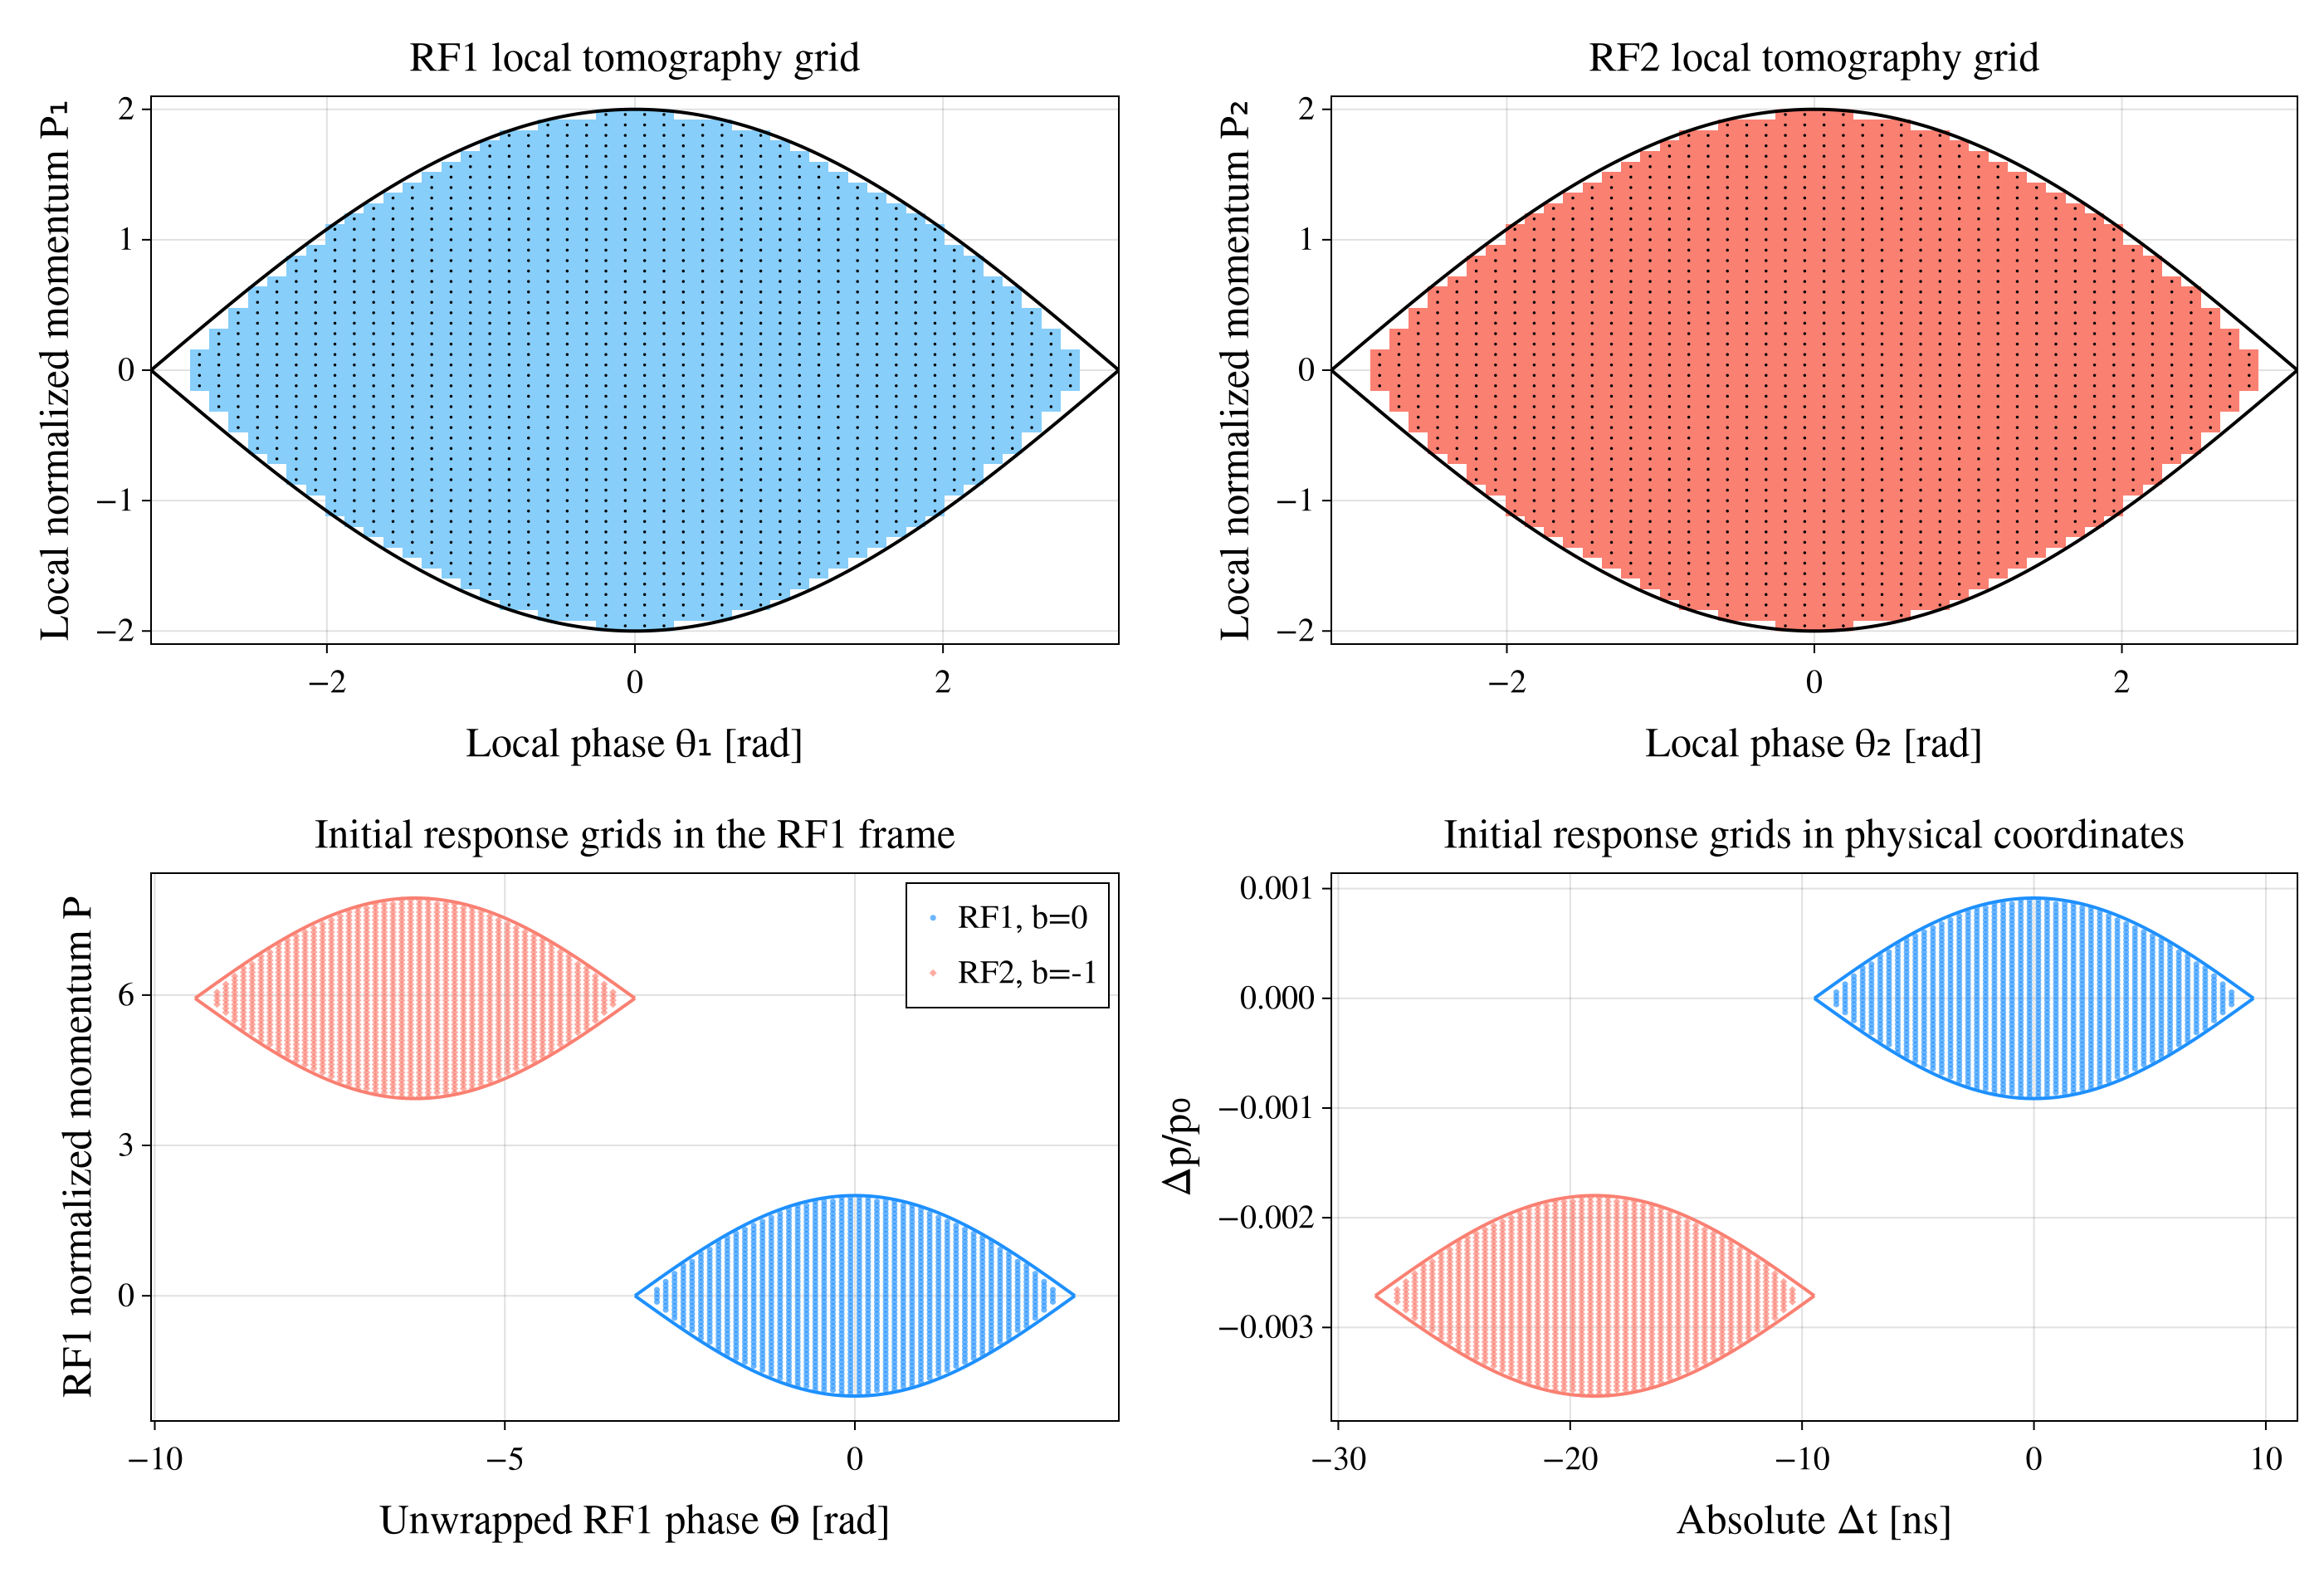

CairoMakie.Screen{IMAGE}


In [21]:
reference_turn = response.reference_turn

rf1_grid = response.rf1_grid
rf2_grid = response.rf2_grid

theta_separatrix_local =
    collect(range(-π, π; length=600))

P_separatrix_local =
    2 .* cos.(theta_separatrix_local ./ 2)

alpha_s_value =
    slip_stacking_parameter(two_rf)

rf2_momentum_scale =
    synchrotron_tune(two_rf.rf2) /
    synchrotron_tune(two_rf.rf1)

energy_to_delta_scale =
    two_rf.rf1.beta_s^2 *
    two_rf.rf1.E_s_eV


grid_figure = Figure(size=(1400, 950))


# ---------------------------------------------------------------------------
# Local RF1 grid
# ---------------------------------------------------------------------------

axis_rf1_local = Axis(
    grid_figure[1, 1];
    xlabel="Local phase θ₁ [rad]",
    ylabel="Local normalized momentum P₁",
    title="RF1 local tomography grid",
)

plot_local_grid!(
    axis_rf1_local,
    rf1_grid;
    color=:lightskyblue,
)


# ---------------------------------------------------------------------------
# Local RF2 grid
# ---------------------------------------------------------------------------

axis_rf2_local = Axis(
    grid_figure[1, 2];
    xlabel="Local phase θ₂ [rad]",
    ylabel="Local normalized momentum P₂",
    title="RF2 local tomography grid",
)

plot_local_grid!(
    axis_rf2_local,
    rf2_grid;
    color=:salmon,
)


# ---------------------------------------------------------------------------
# All grids placed in the unwrapped RF1 normalized frame
# ---------------------------------------------------------------------------

axis_rf1_frame = Axis(
    grid_figure[2, 1];
    xlabel="Unwrapped RF1 phase Θ [rad]",
    ylabel="RF1 normalized momentum P",
    title="Initial response grids in the RF1 frame",
)


# ---------------------------------------------------------------------------
# All grids in physical coordinates
# ---------------------------------------------------------------------------

axis_physical = Axis(
    grid_figure[2, 2];
    xlabel="Absolute Δt [ns]",
    ylabel="Δp/p₀",
    title="Initial response grids in physical coordinates",
)


for spec in response.bucket_specs
    grid_for_spec =
        spec.family == :rf1 ?
        response.rf1_grid :
        response.rf2_grid

    initial_grid = transport_slip_stacked_grid(
        grid_for_spec,
        spec,
        [reference_turn],
        two_rf;
        N0=reference_turn,
    )

    theta_initial =
        vec(initial_grid.theta_absolute)

    P_initial =
        vec(initial_grid.P_rf1)

    delta_t_initial_ns =
        1e9 .* vec(initial_grid.delta_t)

    delta_p_over_p0_initial =
        vec(initial_grid.delta_E_rf1) ./
        energy_to_delta_scale

    bunch_color =
        spec.family == :rf1 ?
        :dodgerblue :
        :salmon

    bunch_marker =
        spec.family == :rf1 ?
        :circle :
        :diamond

    bunch_label =
        "$(uppercase(String(spec.family))), b=$(spec.bucket_index)"

    # Initial grid nodes in normalized RF1 coordinates
    scatter!(
        axis_rf1_frame,
        theta_initial,
        P_initial;
        color=(bunch_color, 0.65),
        marker=bunch_marker,
        markersize=5,
        label=bunch_label,
    )

    # Initial grid nodes in physical coordinates
    scatter!(
        axis_physical,
        delta_t_initial_ns,
        delta_p_over_p0_initial;
        color=(bunch_color, 0.65),
        marker=bunch_marker,
        markersize=5,
    )

    # Bucket-center locations at the reference turn
    phase_center = if spec.family == :rf1
        2π * spec.bucket_index
    else
        2π * spec.bucket_index +
        only(
            rf2_center_phase(
                [reference_turn],
                two_rf;
                N0=reference_turn,
            ),
        )
    end

    momentum_center = if spec.family == :rf1
        0.0
    else
        alpha_s_value
    end

    momentum_scale = if spec.family == :rf1
        1.0
    else
        rf2_momentum_scale
    end

    theta_separatrix_absolute =
        theta_separatrix_local .+
        phase_center

    P_separatrix_upper =
        momentum_center .+
        momentum_scale .* P_separatrix_local

    P_separatrix_lower =
        momentum_center .-
        momentum_scale .* P_separatrix_local

    # Separatrices in normalized RF1 coordinates
    lines!(
        axis_rf1_frame,
        theta_separatrix_absolute,
        P_separatrix_upper;
        color=bunch_color,
        linewidth=2,
    )

    lines!(
        axis_rf1_frame,
        theta_separatrix_absolute,
        P_separatrix_lower;
        color=bunch_color,
        linewidth=2,
    )

    # Convert the separatrix to physical coordinates
    delta_t_separatrix_ns =
        1e9 .* delta_t_from_theta(
            theta_separatrix_absolute,
            two_rf.rf1,
        )

    delta_upper =
        delta_energy_from_P(
            P_separatrix_upper,
            two_rf.rf1,
        ) ./ energy_to_delta_scale

    delta_lower =
        delta_energy_from_P(
            P_separatrix_lower,
            two_rf.rf1,
        ) ./ energy_to_delta_scale

    lines!(
        axis_physical,
        delta_t_separatrix_ns,
        delta_upper;
        color=bunch_color,
        linewidth=2,
    )

    lines!(
        axis_physical,
        delta_t_separatrix_ns,
        delta_lower;
        color=bunch_color,
        linewidth=2,
    )
end


axislegend(
    axis_rf1_frame;
    position=:rt,
    framevisible=true,
)

display(grid_figure)

In [10]:
println("Response-matrix block layout:")

for (spec, column_range) in zip(
    response.bucket_specs,
    response.block_ranges,
)
    @printf(
        "  family=%s, bucket=%3d, columns=%d:%d, cells=%d\n",
        String(spec.family),
        spec.bucket_index,
        first(column_range),
        last(column_range),
        length(column_range),
    )
end

Response-matrix block layout:
  family=rf1, bucket=  0, columns=1:1528, cells=1528
  family=rf2, bucket= -1, columns=1529:3056, cells=1528


In [11]:
# Define a function to compute the Gaussian weights for the grid nodes based on the specified parameters.
function gaussian_grid_weights(grid; theta0, P0, sigma_theta, sigma_P, charge)
    raw = exp.(
        -0.5 .* (
            ((grid.theta_nodes .- theta0) ./ sigma_theta).^2 .+
            ((grid.P_nodes .- P0) ./ sigma_P).^2
        )
    )

    return charge .* raw ./ sum(raw)
end

# Define synthetic ground bunch in RF1
true_rf1_weights = gaussian_grid_weights(
    grid;
    theta0=-0.45,
    P0=0.25,
    sigma_theta=0.42,
    sigma_P=0.32,
    charge=bucket_specs[1].charge_fraction,
)

# Define synthetic ground bunch in RF2
true_rf2_weights = gaussian_grid_weights(
    grid;
    theta0=0.35,
    P0=-0.20,
    sigma_theta=0.50,
    sigma_P=0.28,
    charge=bucket_specs[2].charge_fraction,
)

true_weights = vcat(true_rf1_weights, true_rf2_weights)

matrix_profiles = profiles_from_response(
    response,
    true_weights;
    normalize=false,
)

direct_profiles = direct_slip_stacked_profiles(
    response,
    true_weights,
    two_rf;
    normalize=false,
)

@printf(
    "Matrix vs direct max abs error: %.3e\n",
    maximum(abs.(matrix_profiles .- direct_profiles)),
)

@printf(
    "Total charge per turn: min %.6f, max %.6f\n",
    minimum(vec(sum(matrix_profiles; dims=2))),
    maximum(vec(sum(matrix_profiles; dims=2))),
)

Matrix vs direct max abs error: 2.776e-17
Total charge per turn: min 1.000000, max 1.000000


┌ Warning: No strict ticks found
└ @ PlotUtils /Users/gonza839/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/gonza839/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/gonza839/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/gonza839/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


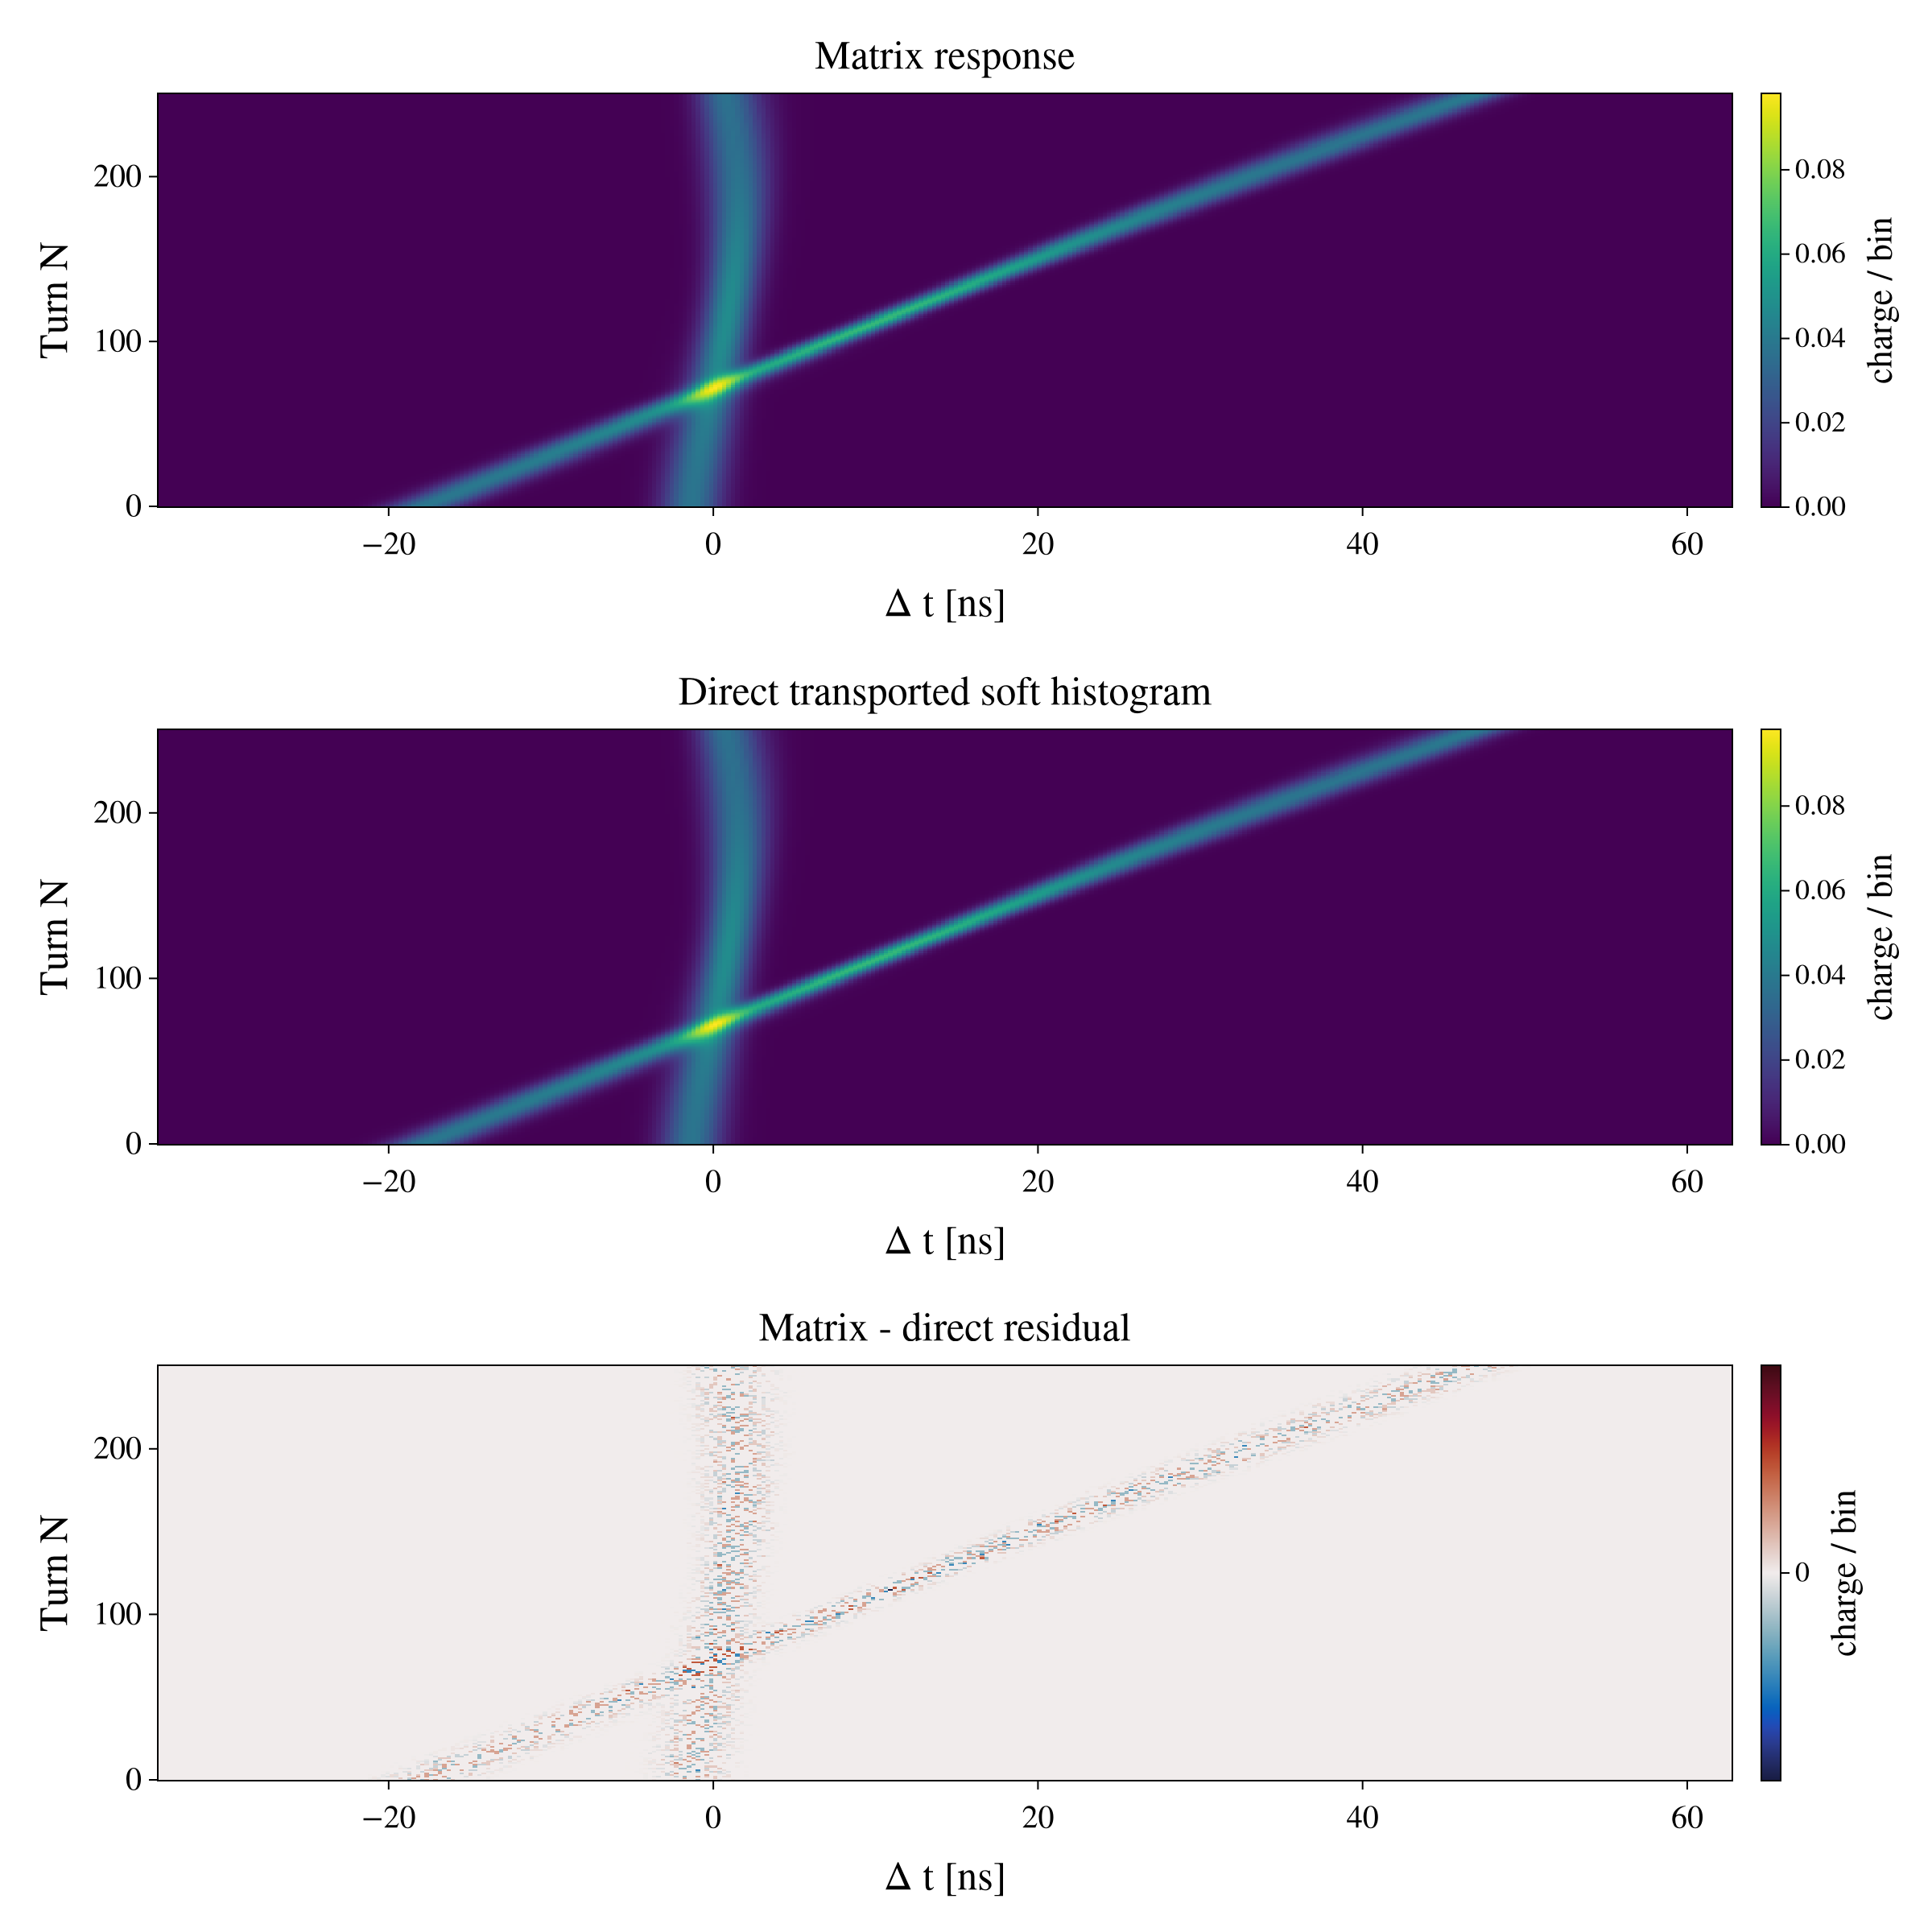

CairoMakie.Screen{IMAGE}


In [12]:
figure_forward = Figure(size=(1200, 1200))

axis_matrix = Axis(
    figure_forward[1, 1];
    xlabel="Δ t [ns]",
    ylabel="Turn N",
    title="Matrix response",
)

matrix_heatmap = heatmap!(
    axis_matrix,
    response.time_bin_centers_s .* 1e9,
    response.turns,
    permutedims(matrix_profiles);
    colormap=:viridis,
)

Colorbar(figure_forward[1, 2], matrix_heatmap; label="charge / bin")

axis_direct = Axis(
    figure_forward[2, 1];
    xlabel="Δ t [ns]",
    ylabel="Turn N",
    title="Direct transported soft histogram",
)

direct_heatmap = heatmap!(
    axis_direct,
    response.time_bin_centers_s .* 1e9,
    response.turns,
    permutedims(direct_profiles);
    colormap=:viridis,
    colorrange=(0, maximum(matrix_profiles)),
)

Colorbar(figure_forward[2, 2], direct_heatmap; label="charge / bin")

residual = matrix_profiles .- direct_profiles
residual_limit = maximum(abs.(residual))

axis_residual = Axis(
    figure_forward[3, 1];
    xlabel="Δ t [ns]",
    ylabel="Turn N",
    title="Matrix - direct residual",
)

residual_heatmap = heatmap!(
    axis_residual,
    response.time_bin_centers_s .* 1e9,
    response.turns,
    permutedims(residual);
    colormap=:balance,
    colorrange=(-residual_limit, residual_limit),
)

Colorbar(figure_forward[3, 2], residual_heatmap; label="charge / bin")

display(figure_forward)

In [ ]:
function reconstruct_slip_stacked_demo(
    response,
    target_profiles;
    iterations=350,
    learning_rate=0.08,
    lambda_tv=0.0,
)
    n_unknowns = size(response.matrix, 2)
    total_charge = mean(vec(sum(target_profiles; dims=2)))

    logits = zeros(Float64, n_unknowns)
    first_moment = zeros(Float64, n_unknowns)
    second_moment = zeros(Float64, n_unknowns)
    loss_history = Float64[]

    beta1 = 0.9
    beta2 = 0.999
    adam_epsilon = 1e-8

    objective(current_logits) = begin
        weights = total_charge .* grid_weights_from_logits(current_logits)
        prediction = profiles_from_response(
            response,
            weights;
            normalize=false,
        )

        profile_mse(prediction, target_profiles) +
            lambda_tv * slip_stacked_grid_total_variation(weights, response)
    end

    for iteration in 1:iterations
        loss_value, pullback = Zygote.pullback(objective, logits)
        gradient = only(pullback(one(loss_value)))

        push!(loss_history, Float64(loss_value))

        first_moment = beta1 .* first_moment .+ (1 - beta1) .* gradient
        second_moment = beta2 .* second_moment .+ (1 - beta2) .* gradient.^2

        corrected_first = first_moment ./ (1 - beta1^iteration)
        corrected_second = second_moment ./ (1 - beta2^iteration)

        logits = logits .-
            learning_rate .* corrected_first ./ (sqrt.(corrected_second) .+ adam_epsilon)
    end

    weights = total_charge .* grid_weights_from_logits(logits)
    profiles = profiles_from_response(response, weights; normalize=false)

    return (
        weights=weights,
        profiles=profiles,
        logits=logits,
        loss_history=loss_history,
    )
end

reconstruction = reconstruct_slip_stacked_demo(
    response,
    matrix_profiles;
    iterations=700,
    learning_rate=0.01,
    lambda_tv=0.0,
)

@printf(
    "Loss: %.6e -> %.6e\n",
    first(reconstruction.loss_history),
    last(reconstruction.loss_history),
)

@printf(
    "Recovered charge: %.6f\n",
    sum(reconstruction.weights),
)

Loss: 5.242834e-05 -> 6.398556e-08
Recovered charge: 1.000000


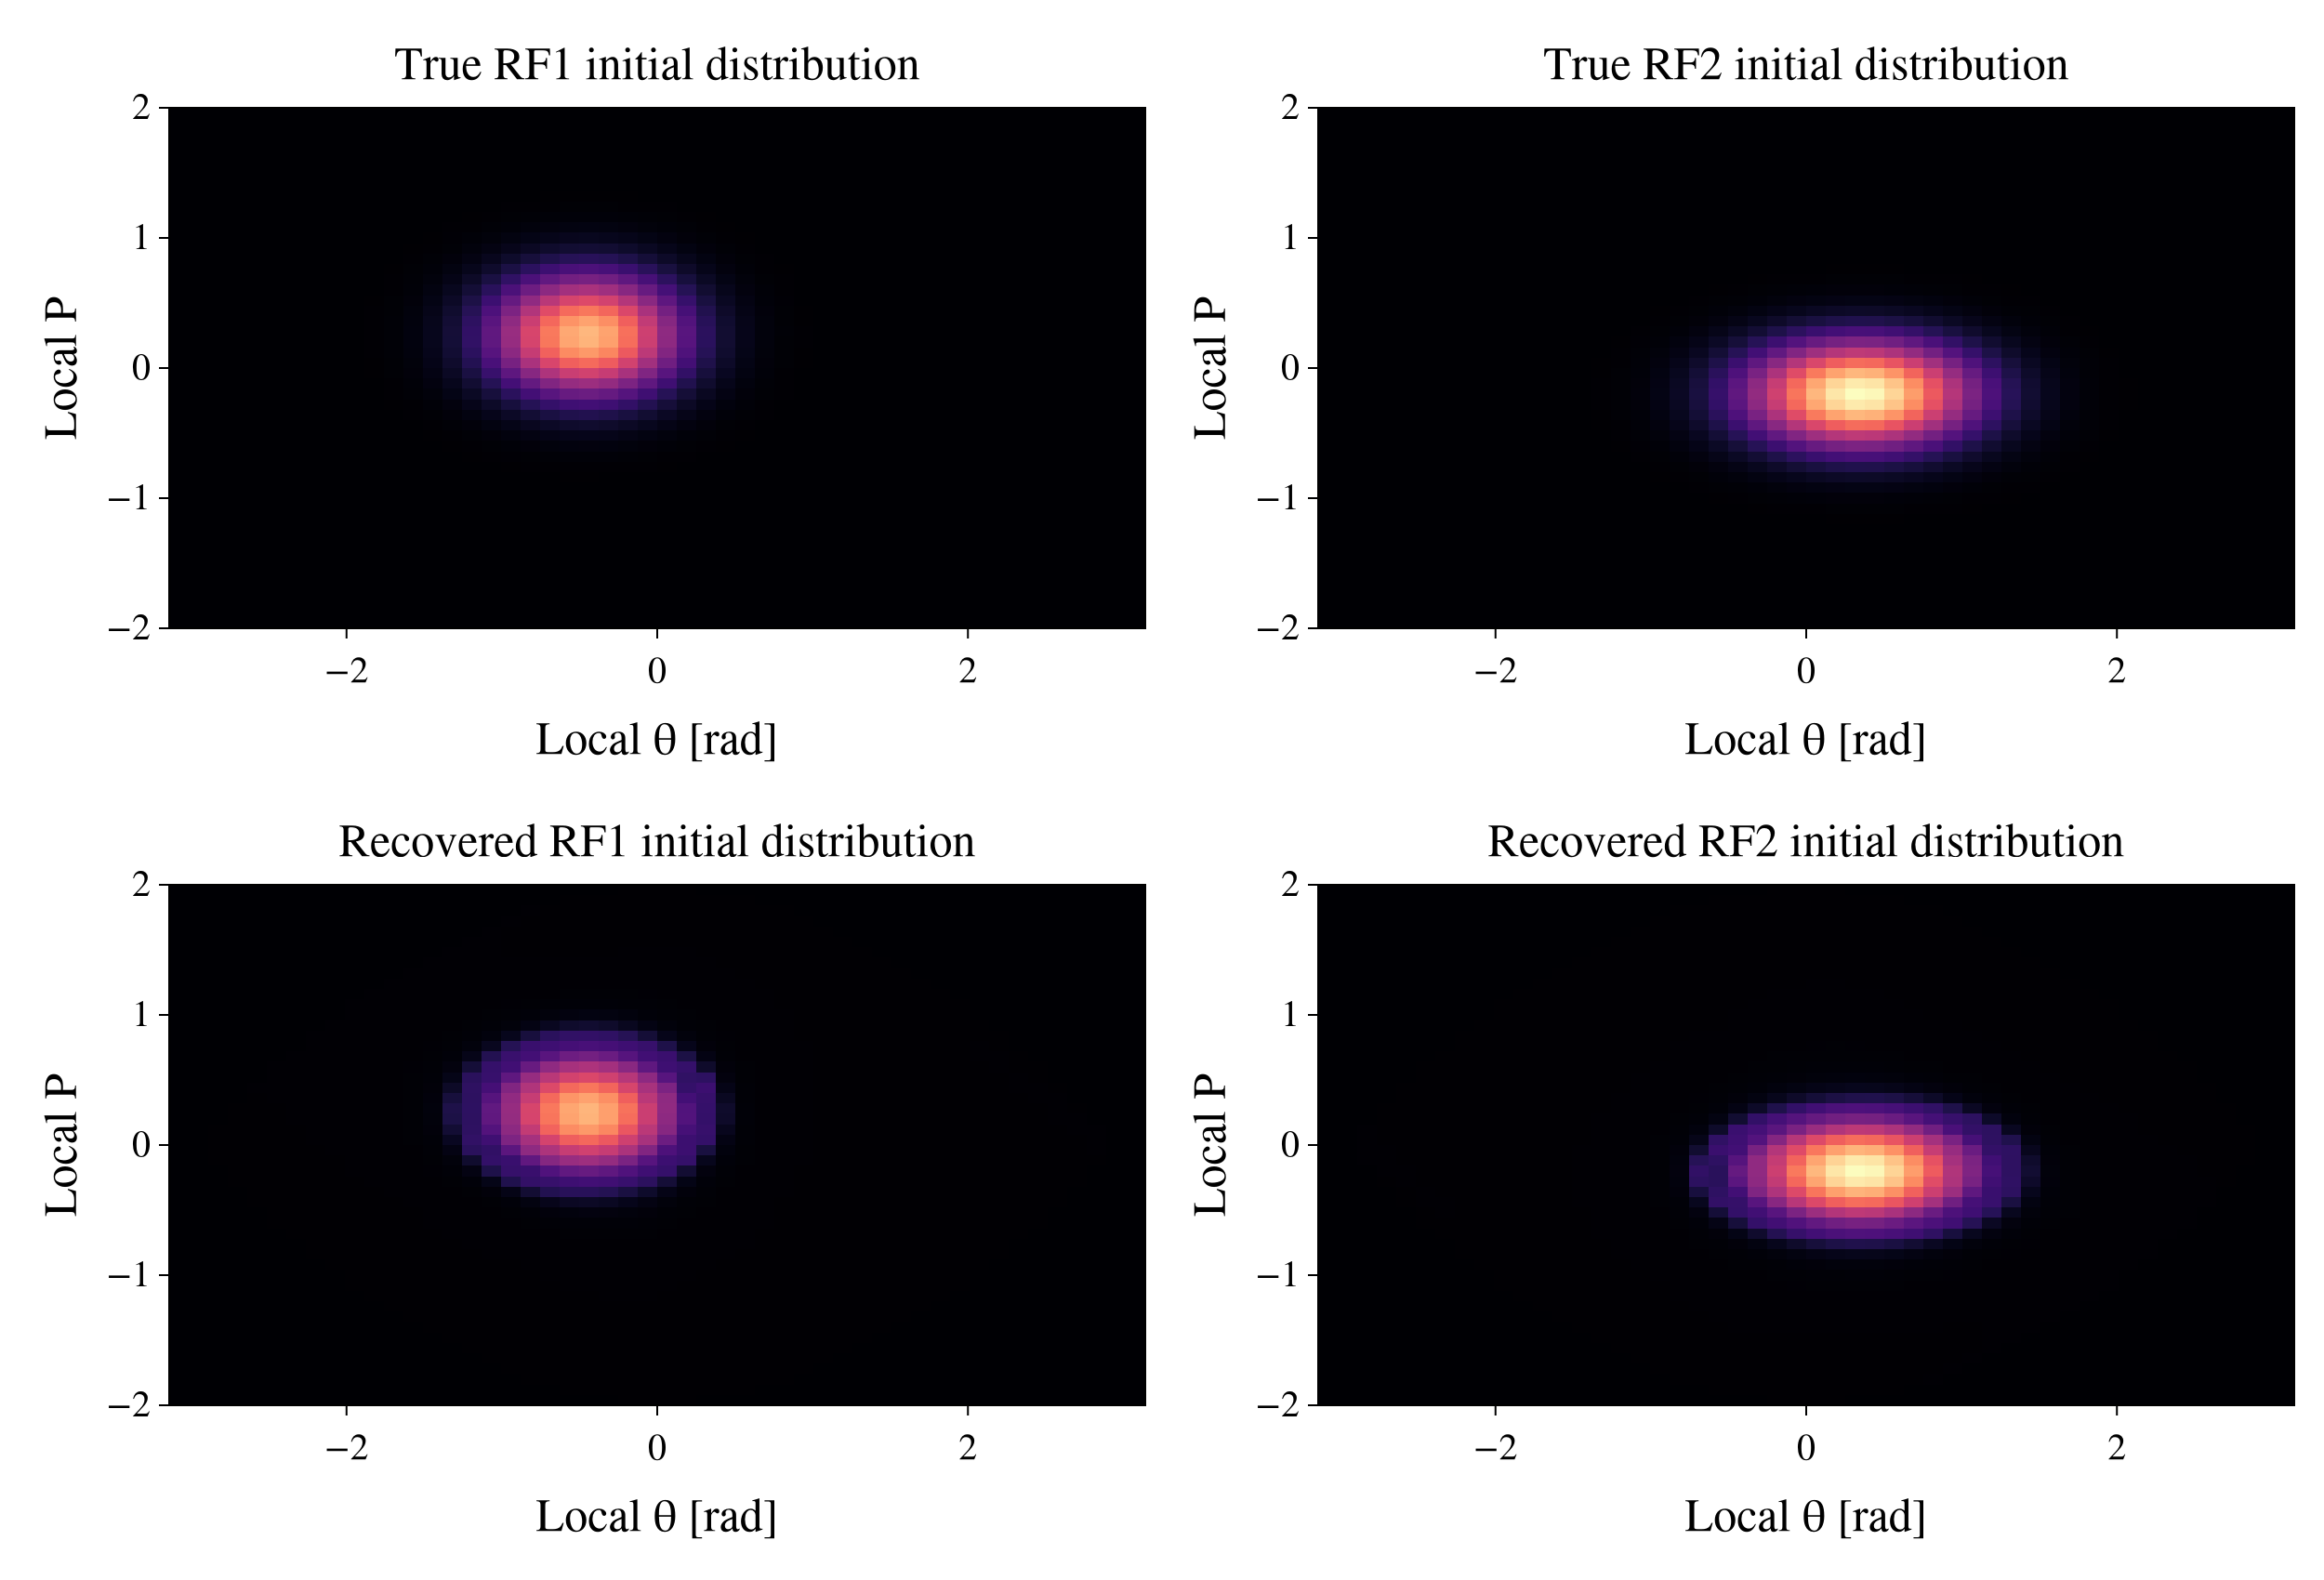

CairoMakie.Screen{IMAGE}


In [19]:

rf1_block = response.block_ranges[1]
rf2_block = response.block_ranges[2]

true_rf1_matrix = grid_weight_matrix(
    grid,
    true_weights[rf1_block];
    fill_value=0.0,
)

true_rf2_matrix = grid_weight_matrix(
    grid,
    true_weights[rf2_block];
    fill_value=0.0,
)

reco_rf1_matrix = grid_weight_matrix(
    grid,
    reconstruction.weights[rf1_block];
    fill_value=0.0,
)

reco_rf2_matrix = grid_weight_matrix(
    grid,
    reconstruction.weights[rf2_block];
    fill_value=0.0,
)

figure_reco = Figure(size=(1250, 850))

common_weight_limit = maximum([
    maximum(true_rf1_matrix),
    maximum(true_rf2_matrix),
    maximum(reco_rf1_matrix),
    maximum(reco_rf2_matrix),
])

for (plot_index, matrix, title) in [
    (1, true_rf1_matrix, "True RF1 initial distribution"),
    (2, true_rf2_matrix, "True RF2 initial distribution"),
    (3, reco_rf1_matrix, "Recovered RF1 initial distribution"),
    (4, reco_rf2_matrix, "Recovered RF2 initial distribution"),
]
    row = plot_index <= 2 ? 1 : 2
    col = plot_index <= 2 ? plot_index : plot_index - 2

    axis = Axis(
        figure_reco[row, col];
        xlabel="Local θ [rad]",
        ylabel="Local P",
        title=title,
    )

    heatmap!(
        axis,
        grid.theta_axis,
        grid.P_axis,
        permutedims(matrix);
        colormap=:magma,
        colorrange=(0, common_weight_limit),
    )
end


display(figure_reco)

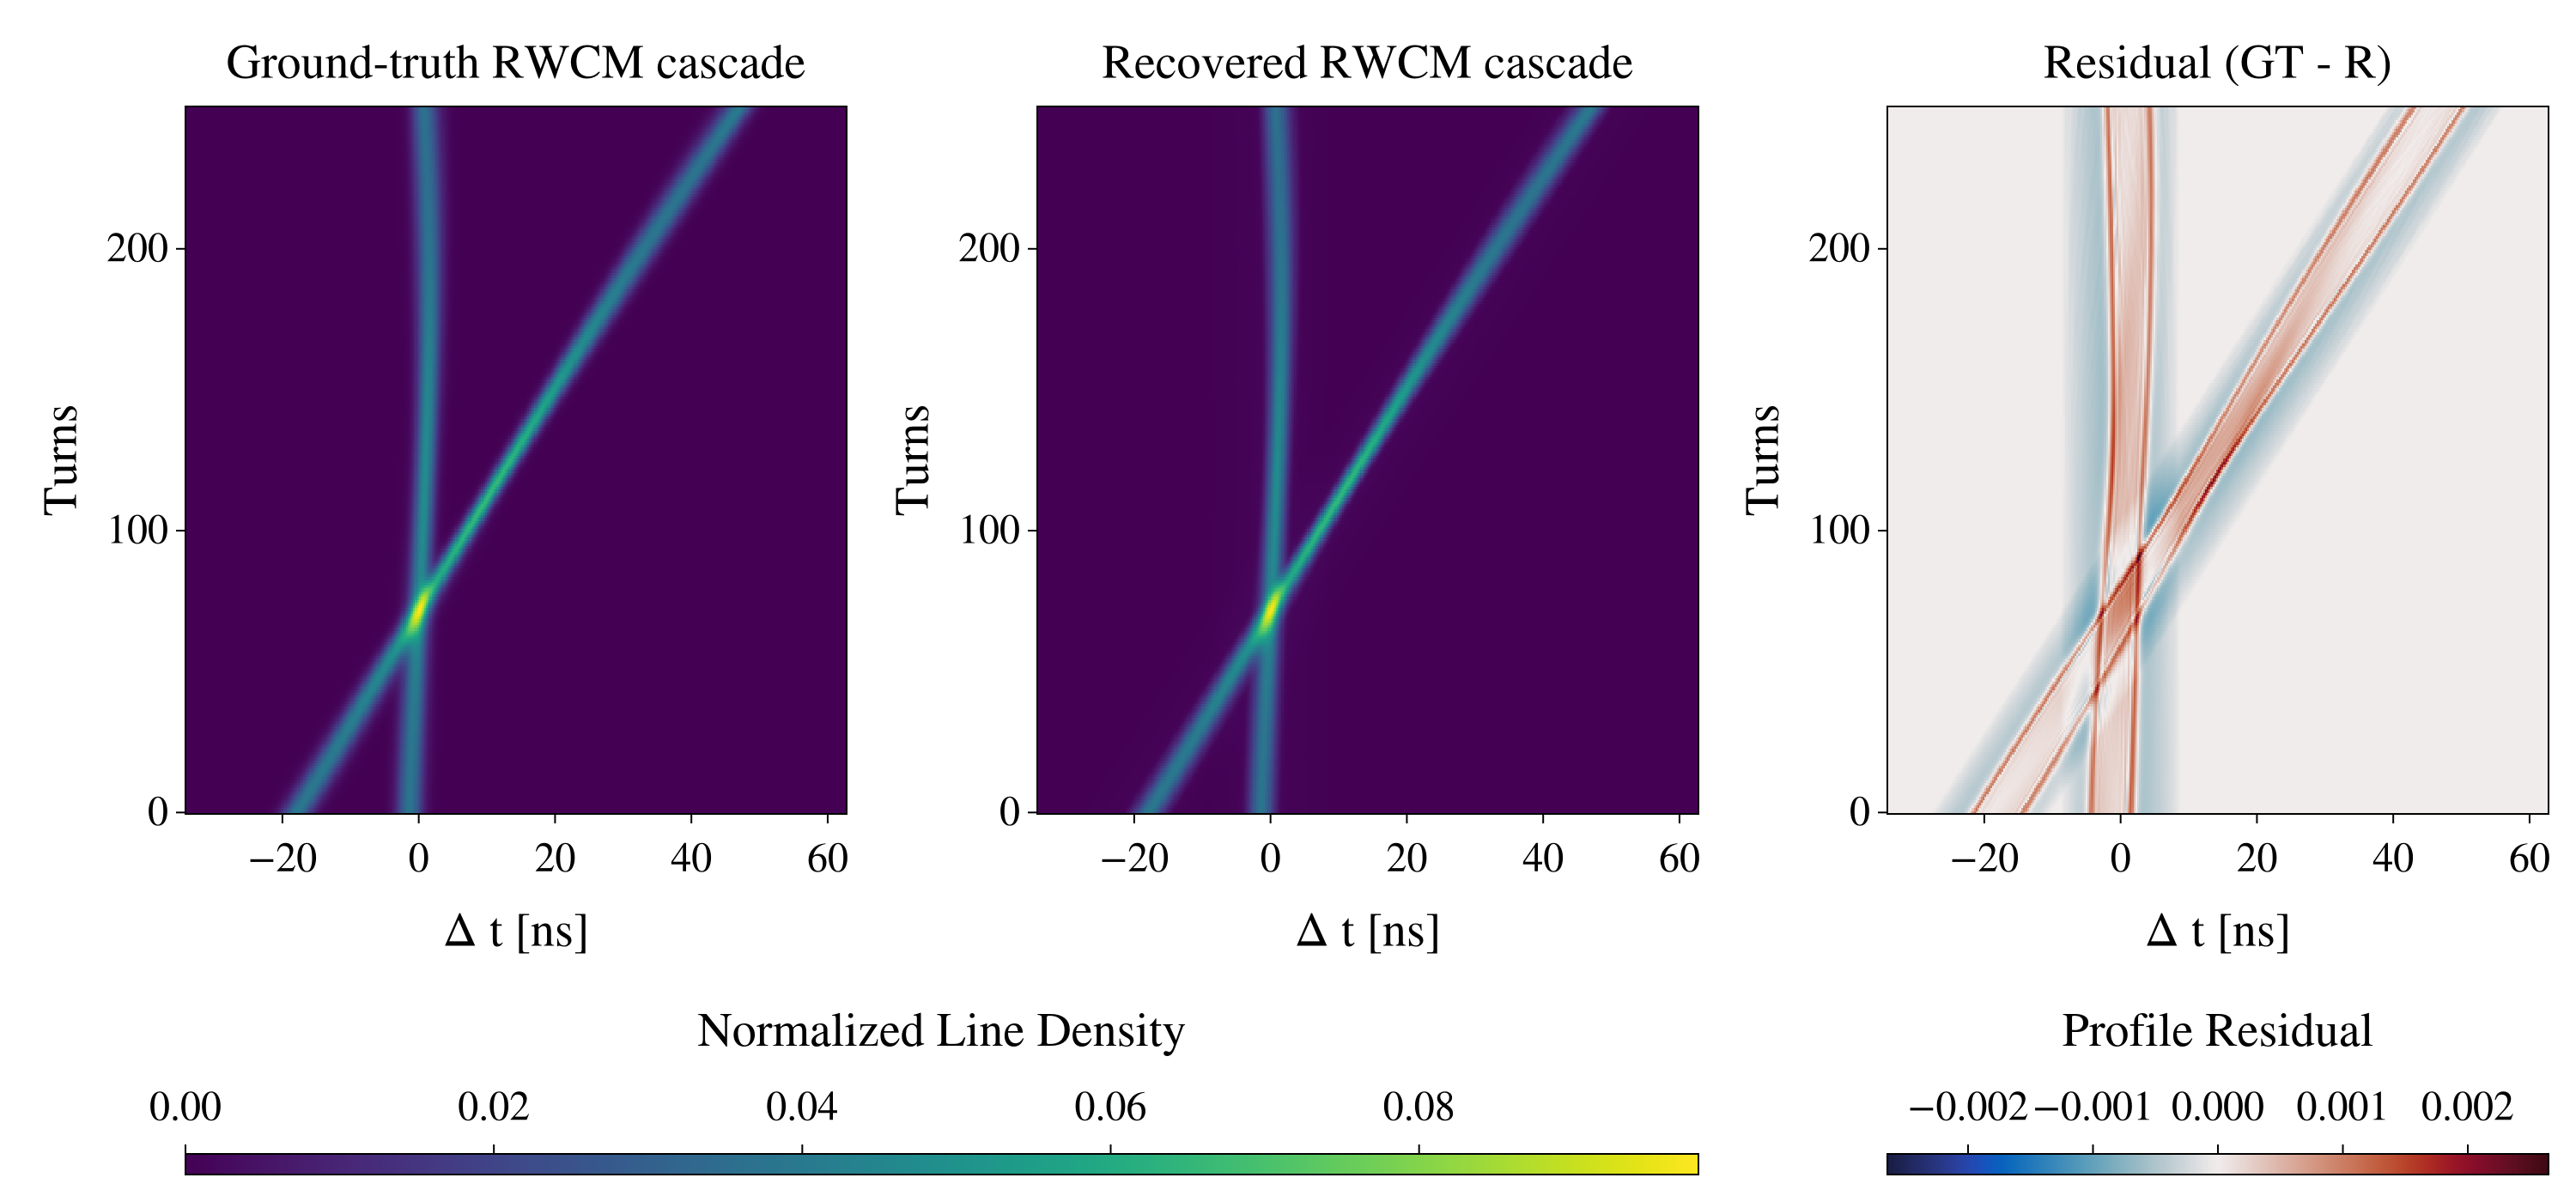

CairoMakie.Screen{IMAGE}


In [36]:
figure_profile_reco = Figure(size=(1500, 700))

target_axis = Axis(
    figure_profile_reco[1, 1];
    xlabel="Δ t [ns]",
    ylabel="Turns",
    title=title="Ground-truth RWCM cascade",
)

target_hm = heatmap!(
    target_axis,
    response.time_bin_centers_s .* 1e9,
    response.turns,
    permutedims(direct_profiles);
    colormap=:viridis,
)

Colorbar(figure_profile_reco[2, 1:2], target_hm,     labelsize = 28,
    ticklabelsize = 24, label = "Normalized Line Density",vertical=false)

prediction_axis = Axis(
    figure_profile_reco[1, 2];
    xlabel="Δ t [ns]",
    ylabel="Turns",
    title="Recovered RWCM cascade",
)

prediction_hm = heatmap!(
    prediction_axis,
    response.time_bin_centers_s .* 1e9,
    response.turns,
    permutedims(reconstruction.profiles);
    colormap=:viridis,
    colorrange=(0, maximum(matrix_profiles)),
)

residual_axis = Axis(
    figure_profile_reco[1, 3];
    xlabel="Δ t [ns]",
    ylabel="Turns",
    title="Residual (GT - R)",
)

residual_hm = heatmap!(
    residual_axis,
    response.time_bin_centers_s .* 1e9,
    response.turns,
    permutedims(direct_profiles .- reconstruction.profiles);
    colormap=:balance,
    colorrange=(-maximum(abs.(direct_profiles .- reconstruction.profiles)), maximum(abs.(direct_profiles .- reconstruction.profiles))),
)

Colorbar(
    figure_profile_reco[2, 3],
    residual_hm;
    vertical=false,
    label="Profile Residual",
    labelsize = 28,
    ticklabelsize = 24,
)

display(figure_profile_reco)

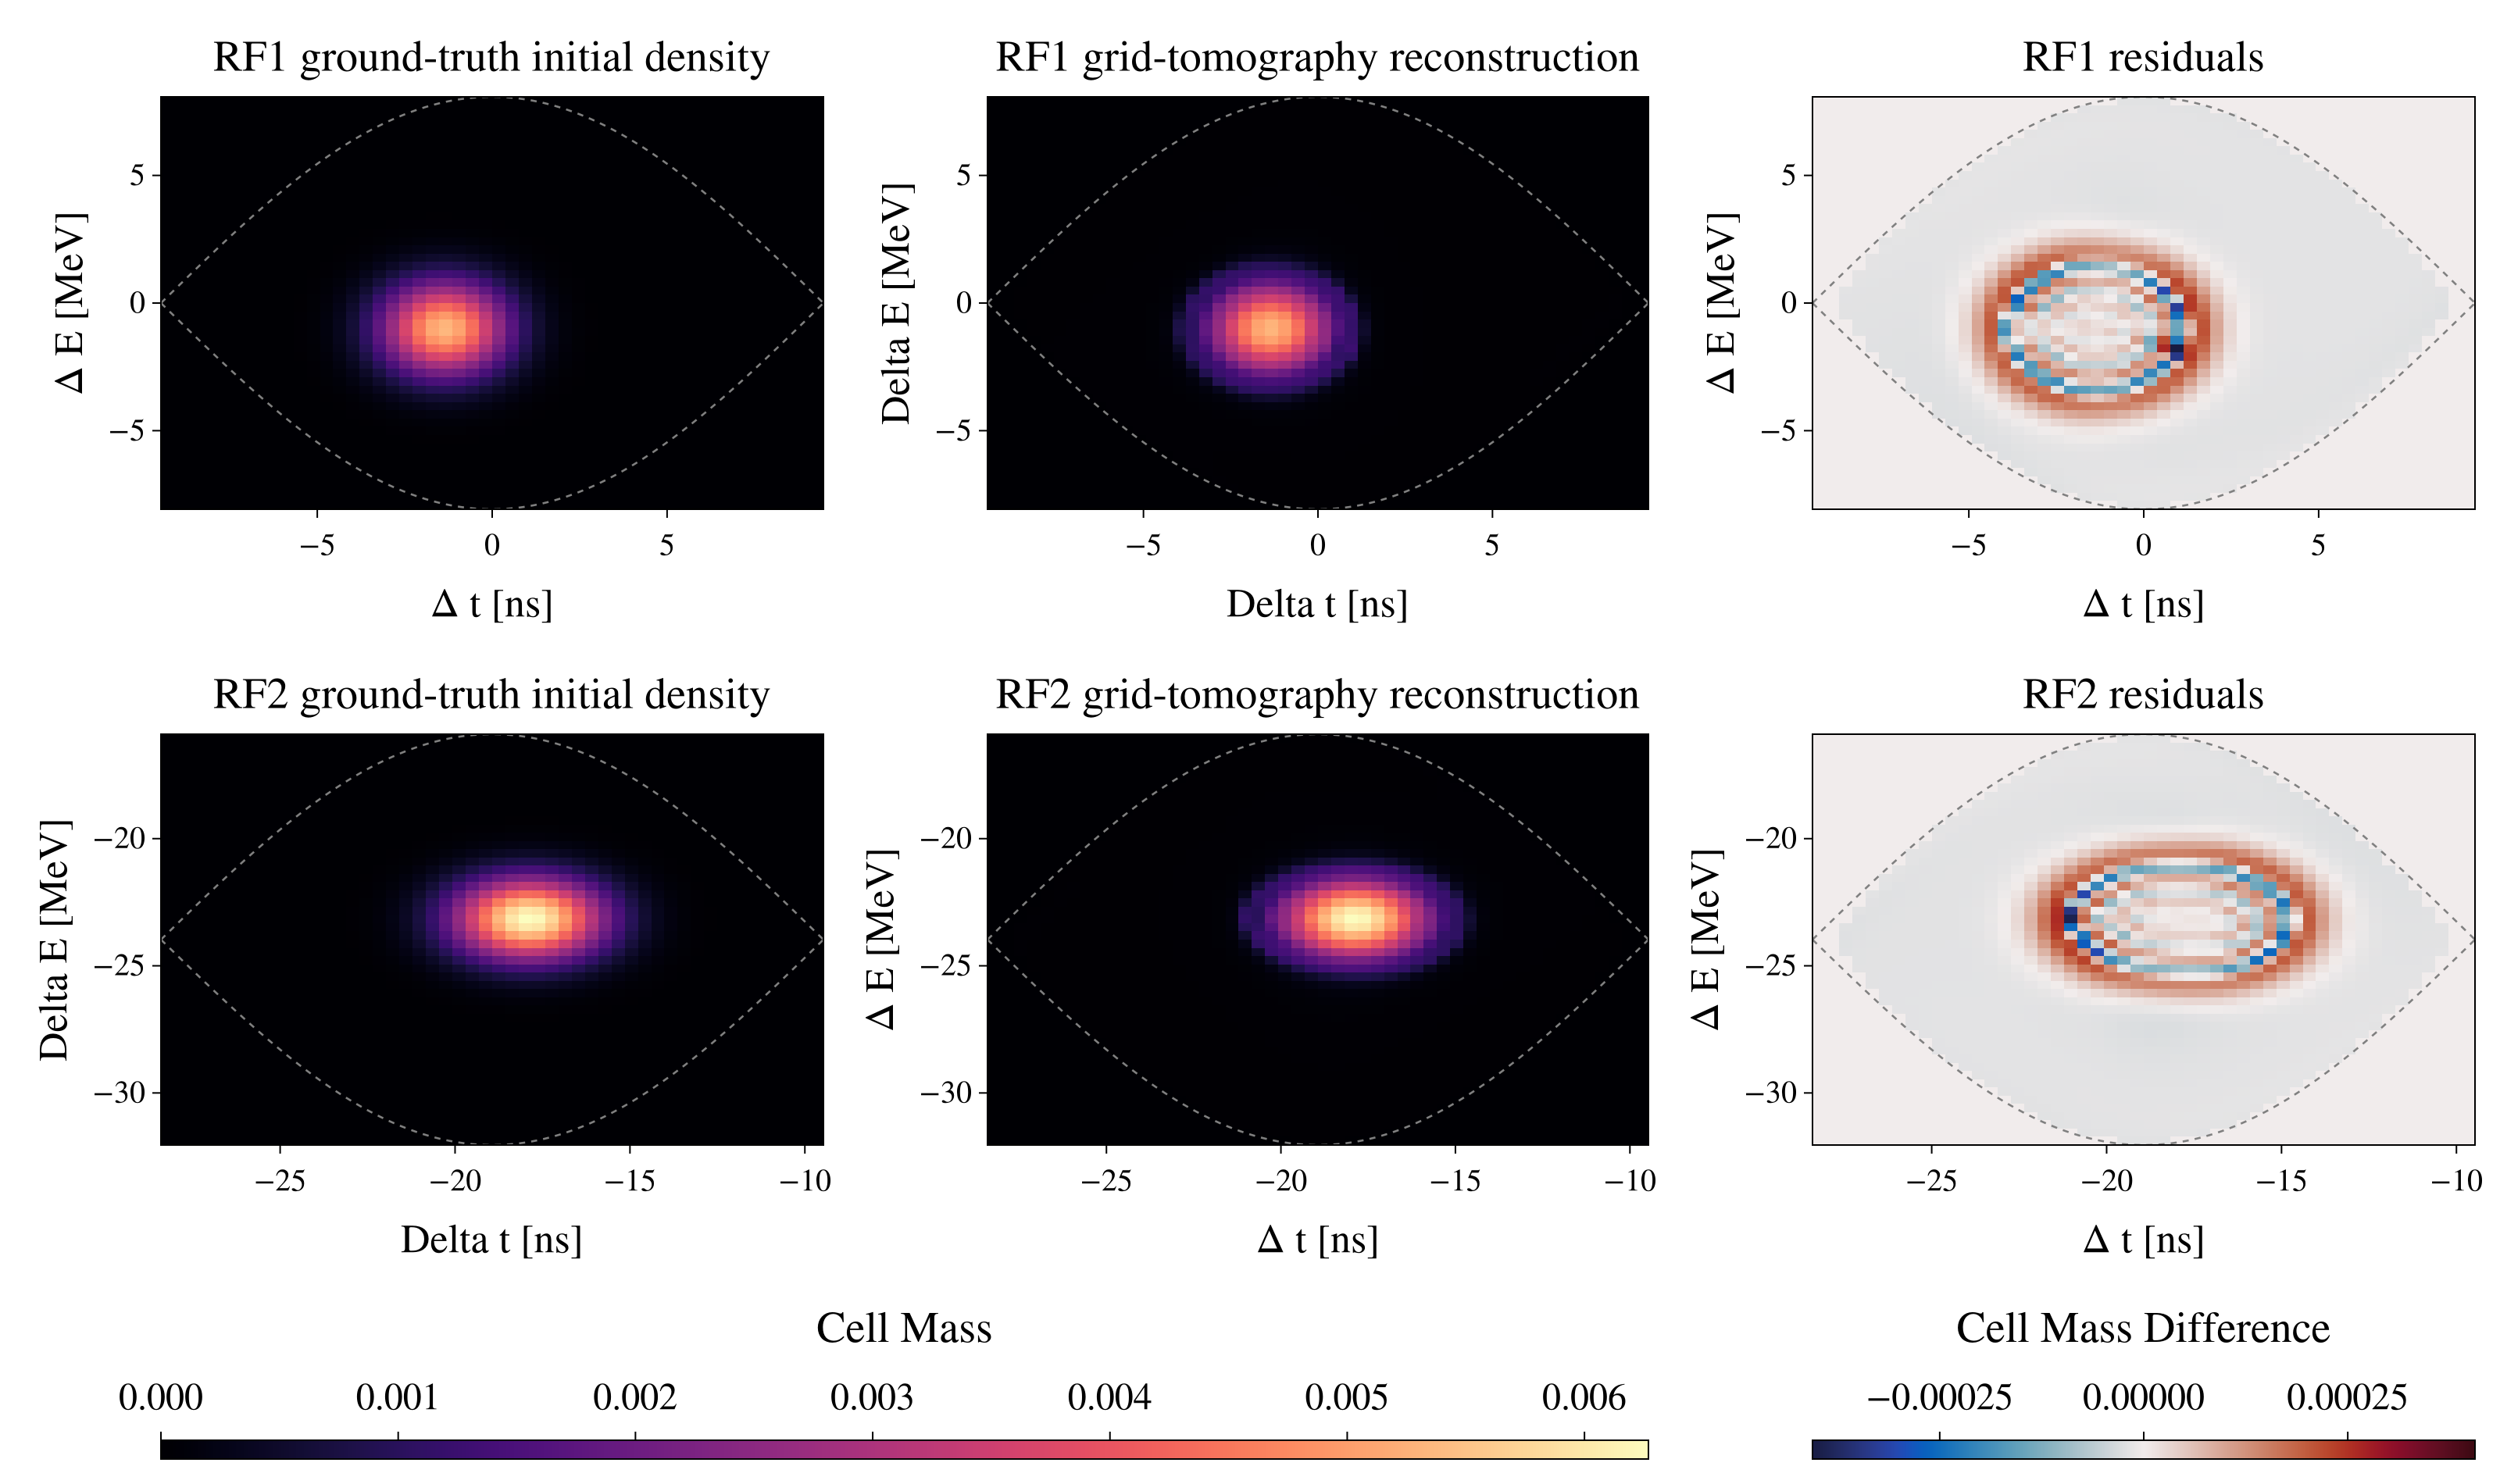

CairoMakie.Screen{IMAGE}


In [32]:
# ------------------------------------------------------------
# Initial-density reconstruction plots in physical coordinates
# One row for RF1 bunch, one row for RF2 bunch
# ------------------------------------------------------------

function heatmap_axes_from_local_grid(
    grid,
    spec::BucketSpec,
    machine::NonInteractingTwoRFMachine;
    turn=first(response.turns),
    N0=response.reference_turn,
)
    if spec.family == :rf1
        theta_axis_absolute =
            grid.theta_axis .+
            2pi * spec.bucket_index

        P_axis_rf1 = grid.P_axis
    elseif spec.family == :rf2
        slip_phase = only(rf2_center_phase([turn], machine; N0=N0))

        theta_axis_absolute =
            grid.theta_axis .+
            2pi * spec.bucket_index .+
            slip_phase

        momentum_scale =
            synchrotron_tune(machine.rf2) /
            synchrotron_tune(machine.rf1)

        P_axis_rf1 =
            momentum_scale .* grid.P_axis .+
            slip_stacking_parameter(machine)
    else
        error("Unknown family $(spec.family)")
    end

    delta_t_axis_ns =
        delta_t_from_theta(theta_axis_absolute, machine.rf1) .* 1e9

    delta_E_axis_MeV =
        delta_energy_from_P(P_axis_rf1, machine.rf1) .* 1e-6

    return delta_t_axis_ns, delta_E_axis_MeV
end

function separatrix_physical_coordinates(
    spec::BucketSpec,
    machine::NonInteractingTwoRFMachine;
    turn=first(response.turns),
    N0=response.reference_turn,
    n_points=700,
)
    theta_local = collect(range(-pi, pi; length=n_points))
    P_upper_local = 2 .* cos.(theta_local ./ 2)
    P_lower_local = -P_upper_local

    if spec.family == :rf1
        theta_absolute =
            theta_local .+
            2pi * spec.bucket_index

        P_upper_rf1 = P_upper_local
        P_lower_rf1 = P_lower_local
    elseif spec.family == :rf2
        slip_phase = only(rf2_center_phase([turn], machine; N0=N0))

        theta_absolute =
            theta_local .+
            2pi * spec.bucket_index .+
            slip_phase

        momentum_scale =
            synchrotron_tune(machine.rf2) /
            synchrotron_tune(machine.rf1)

        P_upper_rf1 =
            slip_stacking_parameter(machine) .+
            momentum_scale .* P_upper_local

        P_lower_rf1 =
            slip_stacking_parameter(machine) .+
            momentum_scale .* P_lower_local
    else
        error("Unknown family $(spec.family)")
    end

    delta_t_ns =
        delta_t_from_theta(theta_absolute, machine.rf1) .* 1e9

    delta_E_upper_MeV =
        delta_energy_from_P(P_upper_rf1, machine.rf1) .* 1e-6

    delta_E_lower_MeV =
        delta_energy_from_P(P_lower_rf1, machine.rf1) .* 1e-6

    return delta_t_ns, delta_E_upper_MeV, delta_E_lower_MeV
end

function orient_for_heatmap(x_axis, y_axis, matrix_P_by_theta)
    heatmap_matrix = permutedims(matrix_P_by_theta)

    if !issorted(x_axis)
        x_order = sortperm(x_axis)
        x_axis = x_axis[x_order]
        heatmap_matrix = heatmap_matrix[x_order, :]
    end

    if !issorted(y_axis)
        y_order = sortperm(y_axis)
        y_axis = y_axis[y_order]
        heatmap_matrix = heatmap_matrix[:, y_order]
    end

    return x_axis, y_axis, heatmap_matrix
end

rf1_spec = bucket_specs[1]
rf2_spec = bucket_specs[2]

rf1_dt_ns, rf1_dE_MeV = heatmap_axes_from_local_grid(
    grid,
    rf1_spec,
    two_rf,
)

rf2_dt_ns, rf2_dE_MeV = heatmap_axes_from_local_grid(
    grid,
    rf2_spec,
    two_rf,
)

rf1_target_dt_ns, rf1_target_dE_MeV, rf1_target_matrix_plot =
    orient_for_heatmap(rf1_dt_ns, rf1_dE_MeV, true_rf1_matrix)

rf1_reco_dt_ns, rf1_reco_dE_MeV, rf1_reco_matrix_plot =
    orient_for_heatmap(rf1_dt_ns, rf1_dE_MeV, reco_rf1_matrix)

rf2_target_dt_ns, rf2_target_dE_MeV, rf2_target_matrix_plot =
    orient_for_heatmap(rf2_dt_ns, rf2_dE_MeV, true_rf2_matrix)

rf2_reco_dt_ns, rf2_reco_dE_MeV, rf2_reco_matrix_plot =
    orient_for_heatmap(rf2_dt_ns, rf2_dE_MeV, reco_rf2_matrix)

rf1_difference_matrix = rf1_target_matrix_plot .- rf1_reco_matrix_plot
rf2_difference_matrix = rf2_target_matrix_plot .- rf2_reco_matrix_plot

rf1_sep_dt_ns, rf1_sep_upper_MeV, rf1_sep_lower_MeV =
    separatrix_physical_coordinates(rf1_spec, two_rf)

rf2_sep_dt_ns, rf2_sep_upper_MeV, rf2_sep_lower_MeV =
    separatrix_physical_coordinates(rf2_spec, two_rf)

common_colorrange = (
    0.0,
    max(
        maximum(rf1_target_matrix_plot),
        maximum(rf1_reco_matrix_plot),
        maximum(rf2_target_matrix_plot),
        maximum(rf2_reco_matrix_plot),
    ),
)

difference_limit = max(
    maximum(abs.(rf1_difference_matrix)),
    maximum(abs.(rf2_difference_matrix)),
    eps(Float64),
)

phase_figure = Figure(size=(1600, 950))

axis_style = (
    titlefont="StixGeneral",
    titlesize=28,
    xlabelfont="StixGeneral",
    ylabelfont="StixGeneral",
    xlabelsize=26,
    ylabelsize=26,
    xticklabelfont="StixGeneral",
    yticklabelfont="StixGeneral",
    xticklabelsize=20,
    yticklabelsize=20,
)

axis_rf1_target = Axis(
    phase_figure[1, 1];
    xlabel="Δ t [ns]",
    ylabel="Δ E [MeV]",
    title="RF1 ground-truth initial density",
    axis_style...,
)

target_heatmap = heatmap!(
    axis_rf1_target,
    rf1_target_dt_ns,
    rf1_target_dE_MeV,
    rf1_target_matrix_plot;
    colormap=:magma,
    colorrange=common_colorrange,
)

axis_rf1_reco = Axis(
    phase_figure[1, 2];
    xlabel="Delta t [ns]",
    ylabel="Delta E [MeV]",
    title="RF1 grid-tomography reconstruction",
    axis_style...,
)

heatmap!(
    axis_rf1_reco,
    rf1_reco_dt_ns,
    rf1_reco_dE_MeV,
    rf1_reco_matrix_plot;
    colormap=:magma,
    colorrange=common_colorrange,
)

axis_rf1_difference = Axis(
    phase_figure[1, 3];
    xlabel="Δ t [ns]",
    ylabel="Δ E [MeV]",
    title="RF1 residuals",
    axis_style...,
)

difference_heatmap = heatmap!(
    axis_rf1_difference,
    rf1_target_dt_ns,
    rf1_target_dE_MeV,
    rf1_difference_matrix;
    colormap=:balance,
    colorrange=(-difference_limit, difference_limit),
)

axis_rf2_target = Axis(
    phase_figure[2, 1];
    xlabel="Delta t [ns]",
    ylabel="Delta E [MeV]",
    title="RF2 ground-truth initial density",
    axis_style...,
)

heatmap!(
    axis_rf2_target,
    rf2_target_dt_ns,
    rf2_target_dE_MeV,
    rf2_target_matrix_plot;
    colormap=:magma,
    colorrange=common_colorrange,
)

axis_rf2_reco = Axis(
    phase_figure[2, 2];
    xlabel="Δ t [ns]",
    ylabel="Δ E [MeV]",
    title="RF2 grid-tomography reconstruction",
    axis_style...,
)

heatmap!(
    axis_rf2_reco,
    rf2_reco_dt_ns,
    rf2_reco_dE_MeV,
    rf2_reco_matrix_plot;
    colormap=:magma,
    colorrange=common_colorrange,
)

axis_rf2_difference = Axis(
    phase_figure[2, 3];
    xlabel="Δ t [ns]",
    ylabel="Δ E [MeV]",
    title="RF2 residuals",
    axis_style...,
)

heatmap!(
    axis_rf2_difference,
    rf2_target_dt_ns,
    rf2_target_dE_MeV,
    rf2_difference_matrix;
    colormap=:balance,
    colorrange=(-difference_limit, difference_limit),
)

for axis in (axis_rf1_target, axis_rf1_reco, axis_rf1_difference)
    lines!(
        axis,
        rf1_sep_dt_ns,
        rf1_sep_upper_MeV;
        color=:gray,
        linestyle=:dash,
        linewidth=1.3,
    )

    lines!(
        axis,
        rf1_sep_dt_ns,
        rf1_sep_lower_MeV;
        color=:gray,
        linestyle=:dash,
        linewidth=1.3,
    )
end

for axis in (axis_rf2_target, axis_rf2_reco, axis_rf2_difference)
    lines!(
        axis,
        rf2_sep_dt_ns,
        rf2_sep_upper_MeV;
        color=:gray,
        linestyle=:dash,
        linewidth=1.3,
    )

    lines!(
        axis,
        rf2_sep_dt_ns,
        rf2_sep_lower_MeV;
        color=:gray,
        linestyle=:dash,
        linewidth=1.3,
    )
end

Colorbar(
    phase_figure[3, 1:2],
    target_heatmap;
    vertical=false,
    label="Cell Mass",
    labelsize=28,
    ticklabelsize=24,
    ticklabelfont="StixGeneral",
    labelfont="StixGeneral",
)

Colorbar(
    phase_figure[3, 3],
    difference_heatmap;
    vertical=false,
    label="Cell Mass Difference",
    labelsize=28,
    ticklabelsize=24,
    ticklabelfont="StixGeneral",
    labelfont="StixGeneral",
)

display(phase_figure)

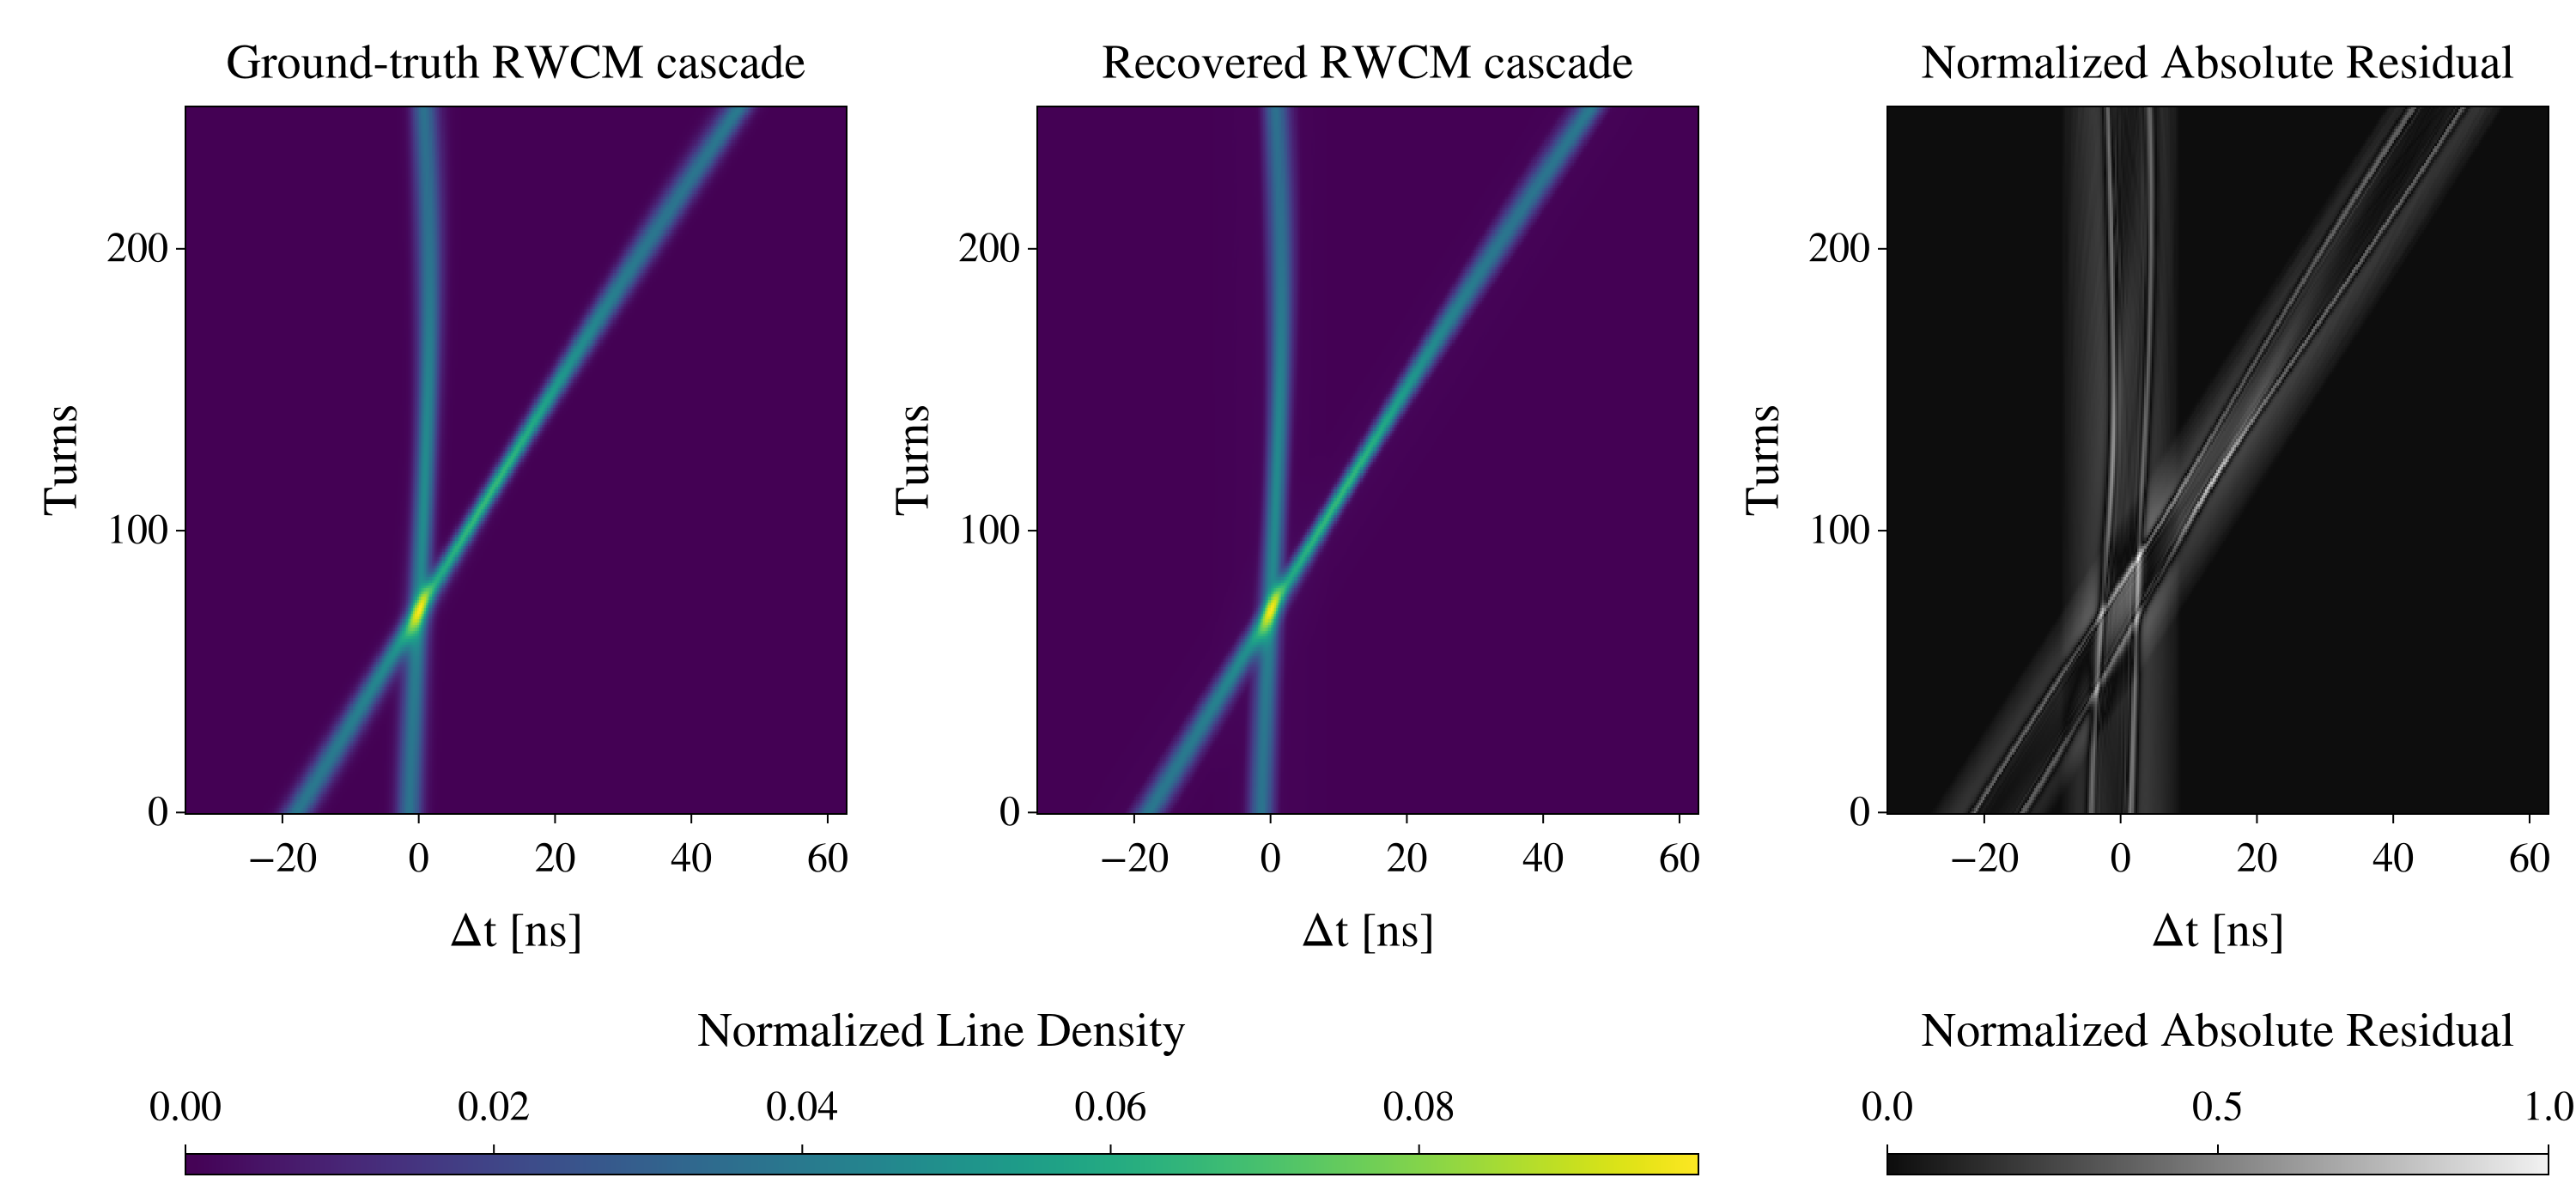

CairoMakie.Screen{IMAGE}


In [50]:
figure_profile_reco = Figure(size=(1500, 700))

target_axis = Axis(
    figure_profile_reco[1, 1];
    xlabel="Δt [ns]",
    ylabel="Turns",
    title=title="Ground-truth RWCM cascade",
)

target_hm = heatmap!(
    target_axis,
    response.time_bin_centers_s .* 1e9,
    response.turns,
    permutedims(direct_profiles);
    colormap=:viridis,
)

Colorbar(figure_profile_reco[2, 1:2], target_hm,     labelsize = 28,
    ticklabelsize = 24, label = "Normalized Line Density",vertical=false)

prediction_axis = Axis(
    figure_profile_reco[1, 2];
    xlabel="Δt [ns]",
    ylabel="Turns",
    title="Recovered RWCM cascade",
)

prediction_hm = heatmap!(
    prediction_axis,
    response.time_bin_centers_s .* 1e9,
    response.turns,
    permutedims(reconstruction.profiles);
    colormap=:viridis,
    colorrange=(0, maximum(matrix_profiles)),
)

residual_axis = Axis(
    figure_profile_reco[1, 3];
    xlabel="Δt [ns]",
    ylabel="Turns",
    title="Normalized Absolute Residual",
)

residual_hm = heatmap!(
    residual_axis,
    response.time_bin_centers_s .* 1e9,
    response.turns,
    permutedims(abs.(direct_profiles .- reconstruction.profiles)/maximum(abs.(direct_profiles .- reconstruction.profiles)));
    colormap=:grays,
    #colorrange=(-maximum(abs.(direct_profiles .- reconstruction.profiles)), maximum(abs.(direct_profiles .- reconstruction.profiles))),
)

Colorbar(
    figure_profile_reco[2, 3],
    residual_hm;
    vertical=false,
    label="Normalized Absolute Residual",
    labelsize = 28,
    ticklabelsize = 24,
)

display(figure_profile_reco)

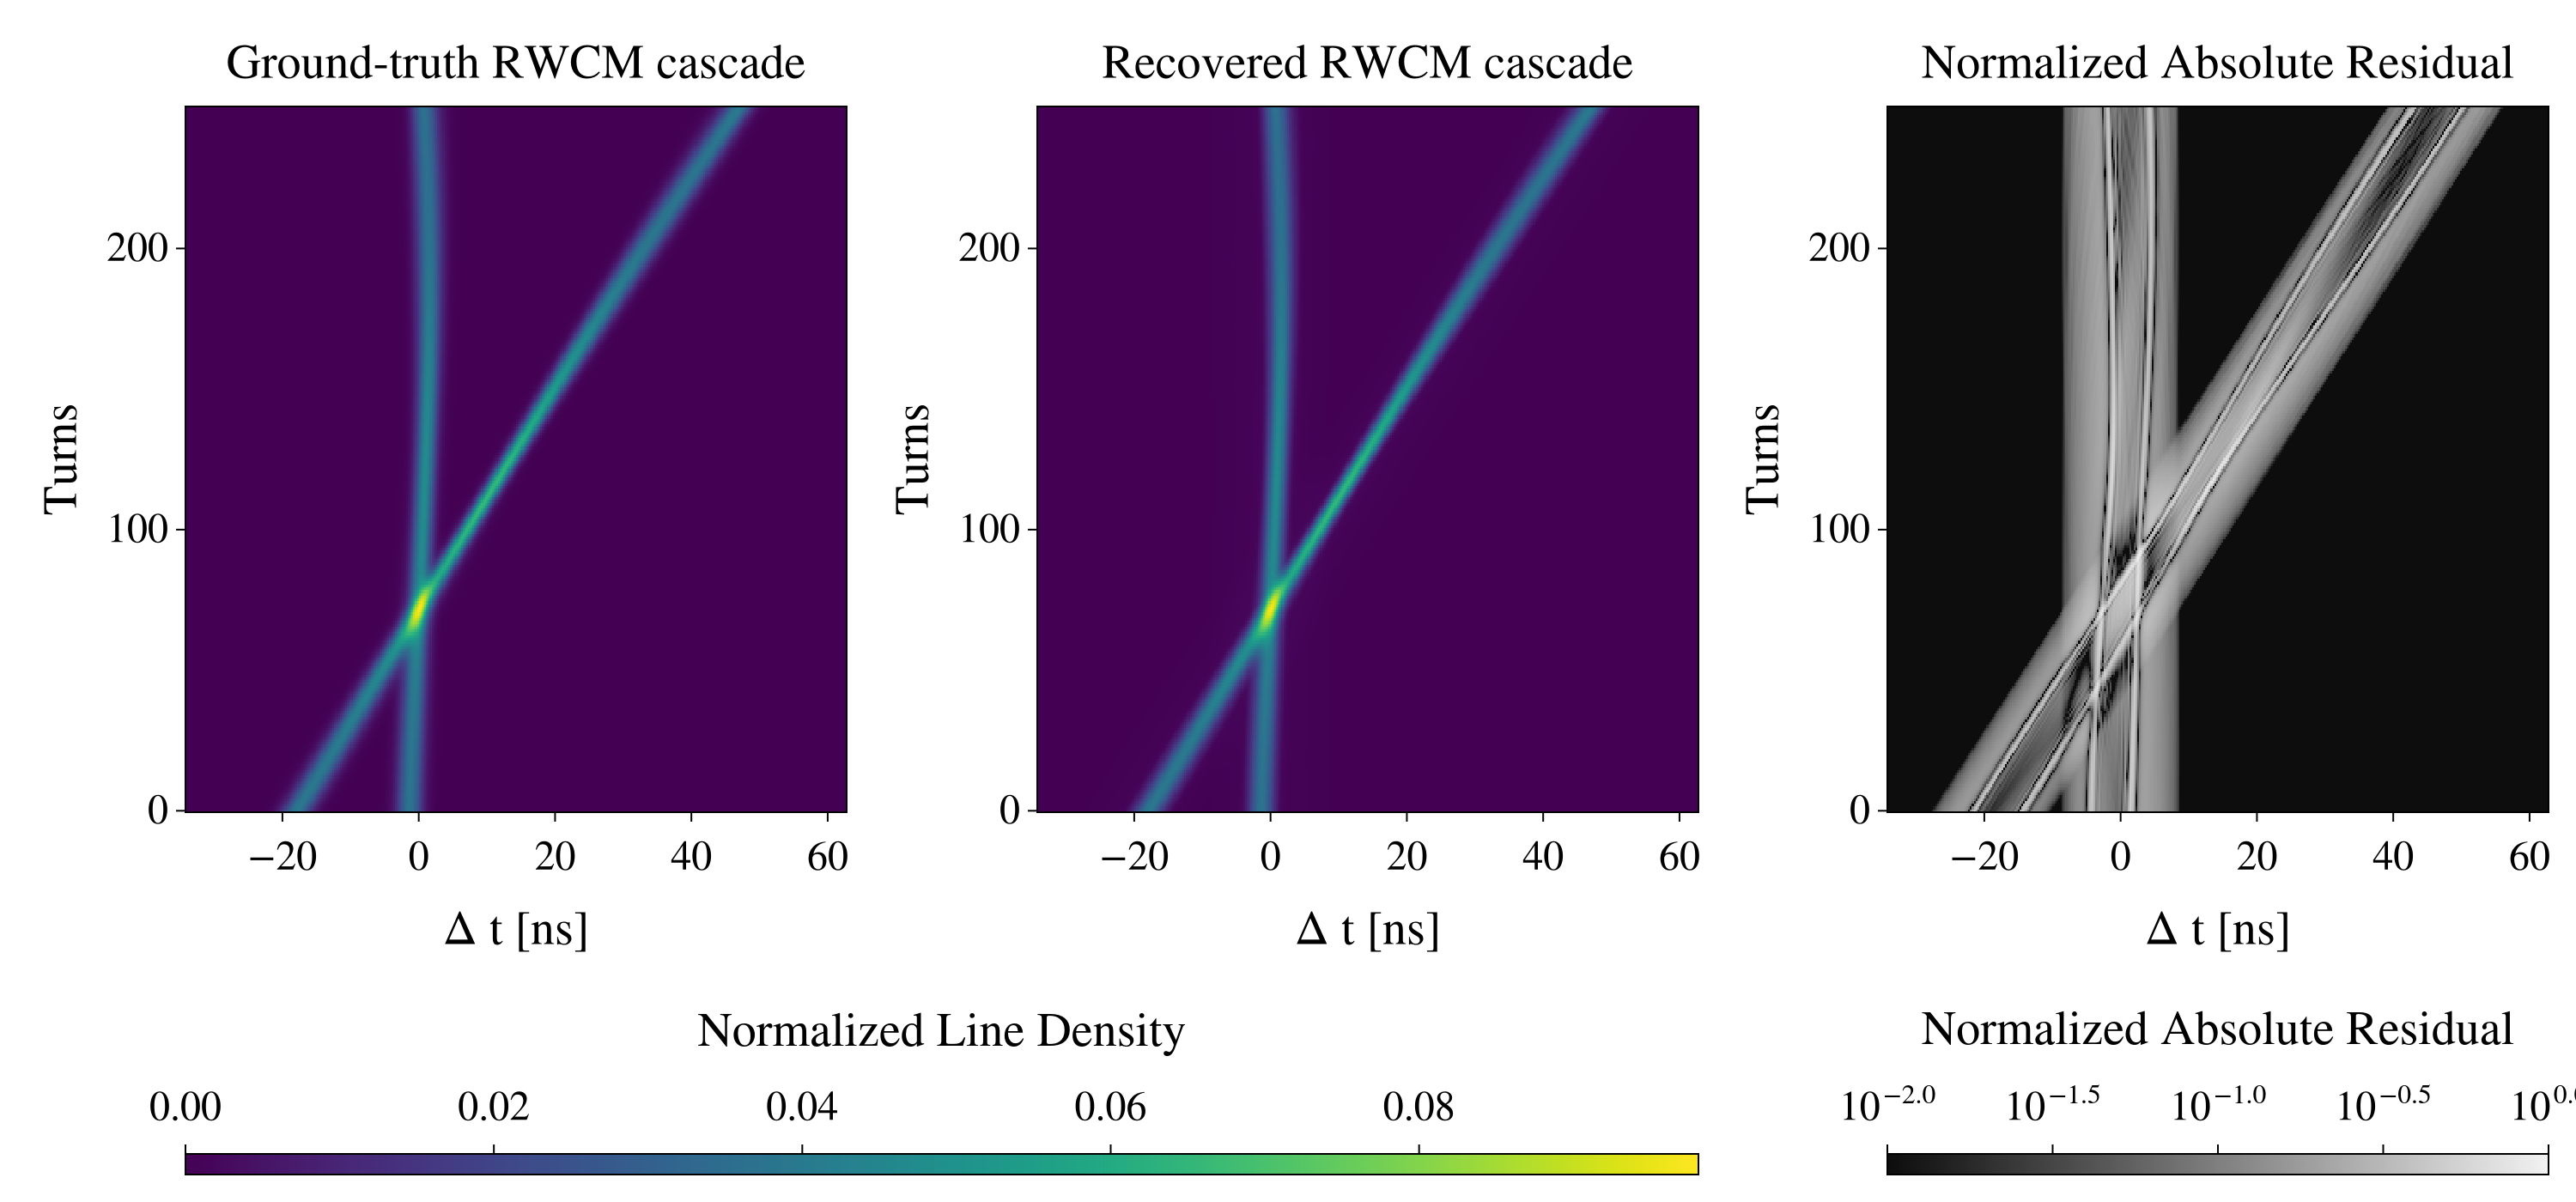

CairoMakie.Screen{IMAGE}


In [ ]:
figure_profile_reco = Figure(size=(1500, 700))

target_axis = Axis(
    figure_profile_reco[1, 1];
    xlabel="Δ t [ns]",
    ylabel="Turns",
    title=title="Ground-truth RWCM cascade",
)

target_hm = heatmap!(
    target_axis,
    response.time_bin_centers_s .* 1e9,
    response.turns,
    permutedims(direct_profiles);
    colormap=:viridis,
)

Colorbar(figure_profile_reco[2, 1:2], target_hm,     labelsize = 28,
    ticklabelsize = 24, label = "Normalized Line Density",vertical=false)

prediction_axis = Axis(
    figure_profile_reco[1, 2];
    xlabel="Δ t [ns]",
    ylabel="Turns",
    title="Recovered RWCM cascade",
)

prediction_hm = heatmap!(
    prediction_axis,
    response.time_bin_centers_s .* 1e9,
    response.turns,
    permutedims(reconstruction.profiles);
    colormap=:viridis,
    colorrange=(0, maximum(matrix_profiles)),
)

residual_axis = Axis(
    figure_profile_reco[1, 3];
    xlabel="Δ t [ns]",
    ylabel="Turns",
    title="Normalized Absolute Residual",
)

# Calculate the normalized residual matrix safely
residual_matrix = abs.(direct_profiles .- reconstruction.profiles) ./ maximum(abs.(direct_profiles .- reconstruction.profiles))

residual_hm = heatmap!(
    residual_axis,
    response.time_bin_centers_s .* 1e9,
    response.turns,
    permutedims(residual_matrix);
    colormap=:grays,
    colorscale = log10,          # Makes the colormap logarithmic
    colorrange = (1e-2, 1.0),    # Prevents log10(0) errors by setting a lower floor (e.g., 10⁻⁴)
)

Colorbar(
    figure_profile_reco[2, 3], 
    residual_hm; 
    vertical=false, 
    label="Normalized Absolute Residual", 
    labelsize = 28, 
    ticklabelsize = 24,
)

display(figure_profile_reco)
